📁 Folder: Figures_5k_epochs
✅ Metrics: 5 epochs
📊 5000 epochs → Overall: 0.9234
✅ Real: (292, 41)


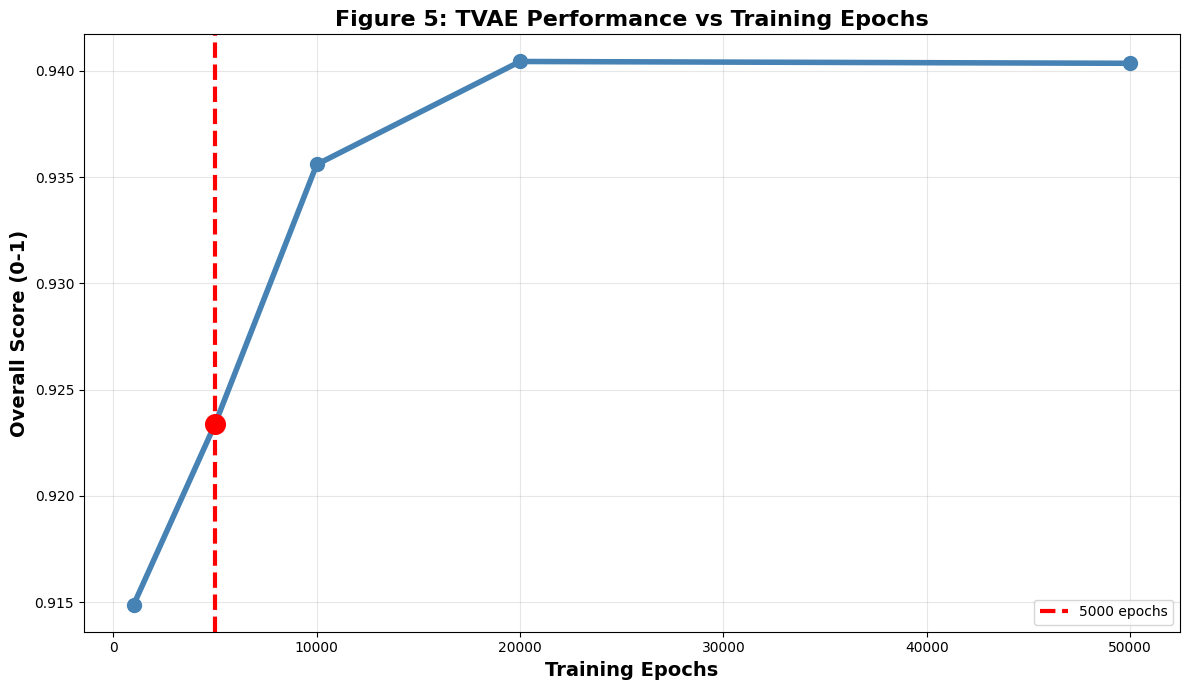

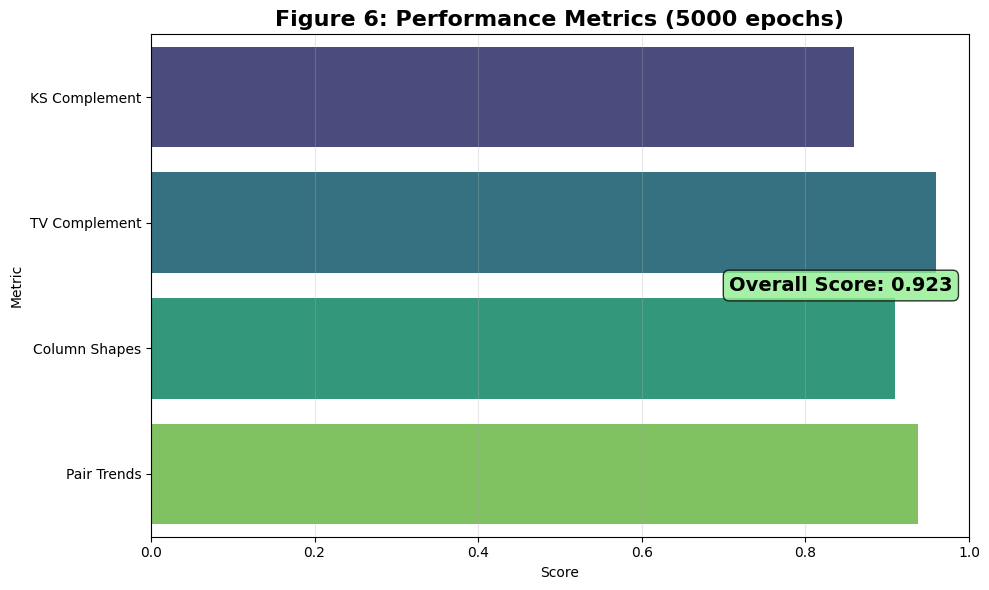


📋 Table 3 (5000 epochs):
   epochs  column_shapes  mean_KS_complement  mean_TV_complement  \
1    5000         0.9095              0.8591                0.96   

   column_pair_trends  overall_score  
1              0.9372         0.9234  
✅ 8 distribuzioni!

🎉 ✅ Figures_5k_epochs/
  📄 Fig5_Trends_5k.png
  📄 Fig6_Metrics_5k.png
  📄 FigS1_Sex_5k.png
  📄 FigS2_Age_5k.png
  📄 FigS3_Height_5k.png
  📄 FigS4_Weight_5k.png
  📄 FigS5_BMI_5k.png
  📄 FigS6_Smoking_5k.png
  📄 FigS7_Atrial Fibrillation_5k.png
  📄 FigS8_ischaemic heart disease_5k.png
  📄 Paper_Table3_5k.csv


In [16]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

fig_folder = "Figures_5k_epochs"
os.makedirs(fig_folder, exist_ok=True)
print(f" Folder: {fig_folder}")


metrics_files = list(Path(".").glob("*metrics_table*.csv"))
metrics_df = pd.read_csv(metrics_files[-1])
print(f" Metrics: {len(metrics_df)} epochs")


row_5k = metrics_df[metrics_df['epochs'] == 5000].iloc[0]
print(f" 5000 epochs → Overall: {row_5k['overall_score']:.4f}")

df_real = None
try:
    df_real = pd.read_excel("DB_orig_totale.xlsx").drop(columns=["ID"], errors='ignore')
    print(f" Real: {df_real.shape}")
except:
    print("No Excel")

plt.figure(figsize=(12, 7))
plt.plot(metrics_df['epochs'], metrics_df['overall_score'], 'o-', lw=4, markersize=10, color='steelblue')
plt.axvline(5000, color='red', ls='--', lw=3, label='5000 epochs')
plt.scatter([5000], [row_5k['overall_score']], s=200, color='red', zorder=5)
plt.xlabel('Training Epochs', fontsize=14, fontweight='bold')
plt.ylabel('Overall Score (0-1)', fontsize=14, fontweight='bold')
plt.title('Figure 5: TVAE Performance vs Training Epochs', fontsize=16, fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{fig_folder}/Fig5_Trends_5k.png", dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
metrics_data = {
    'Metric': ['KS Complement', 'TV Complement', 'Column Shapes', 'Pair Trends'],
    'Score': [row_5k['mean_KS_complement'], row_5k['mean_TV_complement'], 
              row_5k['column_shapes'], row_5k['column_pair_trends']]
}
df_metrics = pd.DataFrame(metrics_data)

sns.barplot(data=df_metrics, x='Score', y='Metric', palette='viridis', ax=ax)
ax.set_xlim(0, 1)
ax.set_title('Figure 6: Performance Metrics (5000 epochs)', fontsize=16, fontweight='bold')
ax.grid(alpha=0.3, axis='x')
ax.text(0.98, 0.5, f'Overall Score: {row_5k["overall_score"]:.3f}', 
        transform=ax.transAxes, ha='right', va='center', fontsize=14, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.8))
plt.tight_layout()
plt.savefig(f"{fig_folder}/Fig6_Metrics_5k.png", dpi=300, bbox_inches='tight')
plt.show()

table3 = metrics_df[metrics_df['epochs']==5000][['epochs','column_shapes','mean_KS_complement',
                                                 'mean_TV_complement','column_pair_trends','overall_score']].round(4)
table3.to_csv(f"{fig_folder}/Paper_Table3_5k.csv", index=False)
print("\n Table 3 (5000 epochs):")
print(table3)

if df_real is not None:
    cont_cols = df_real.select_dtypes(np.number).columns[:8]  # Top 8 veloce
    
    for i, col in enumerate(cont_cols):
        plt.figure(figsize=(8, 5))
        if not df_real[col].dropna().empty:
            sns.kdeplot(df_real[col].dropna(), label="Real", fill=True, alpha=0.6, color="blue")
        plt.title(f"Fig S{i+1}: {col} (5000 epochs)", fontsize=14, fontweight='bold')
        plt.xlabel(col); plt.ylabel("Density"); plt.legend(); plt.grid(alpha=0.3)
        plt.savefig(f"{fig_folder}/FigS{i+1}_{col.replace('/','_')}_5k.png", dpi=300)
        plt.close()
    
    print(f"{len(cont_cols)} distribuzioni!")

print(f"\n{fig_folder}/")
for f in Path(fig_folder).iterdir():
    print(f"{f.name}")

In [17]:
df_syn_5x = pd.read_excel('DB_synth_totale.xlsx')

📊 21 Continuous Distributions: GRIGLIA 3x7...


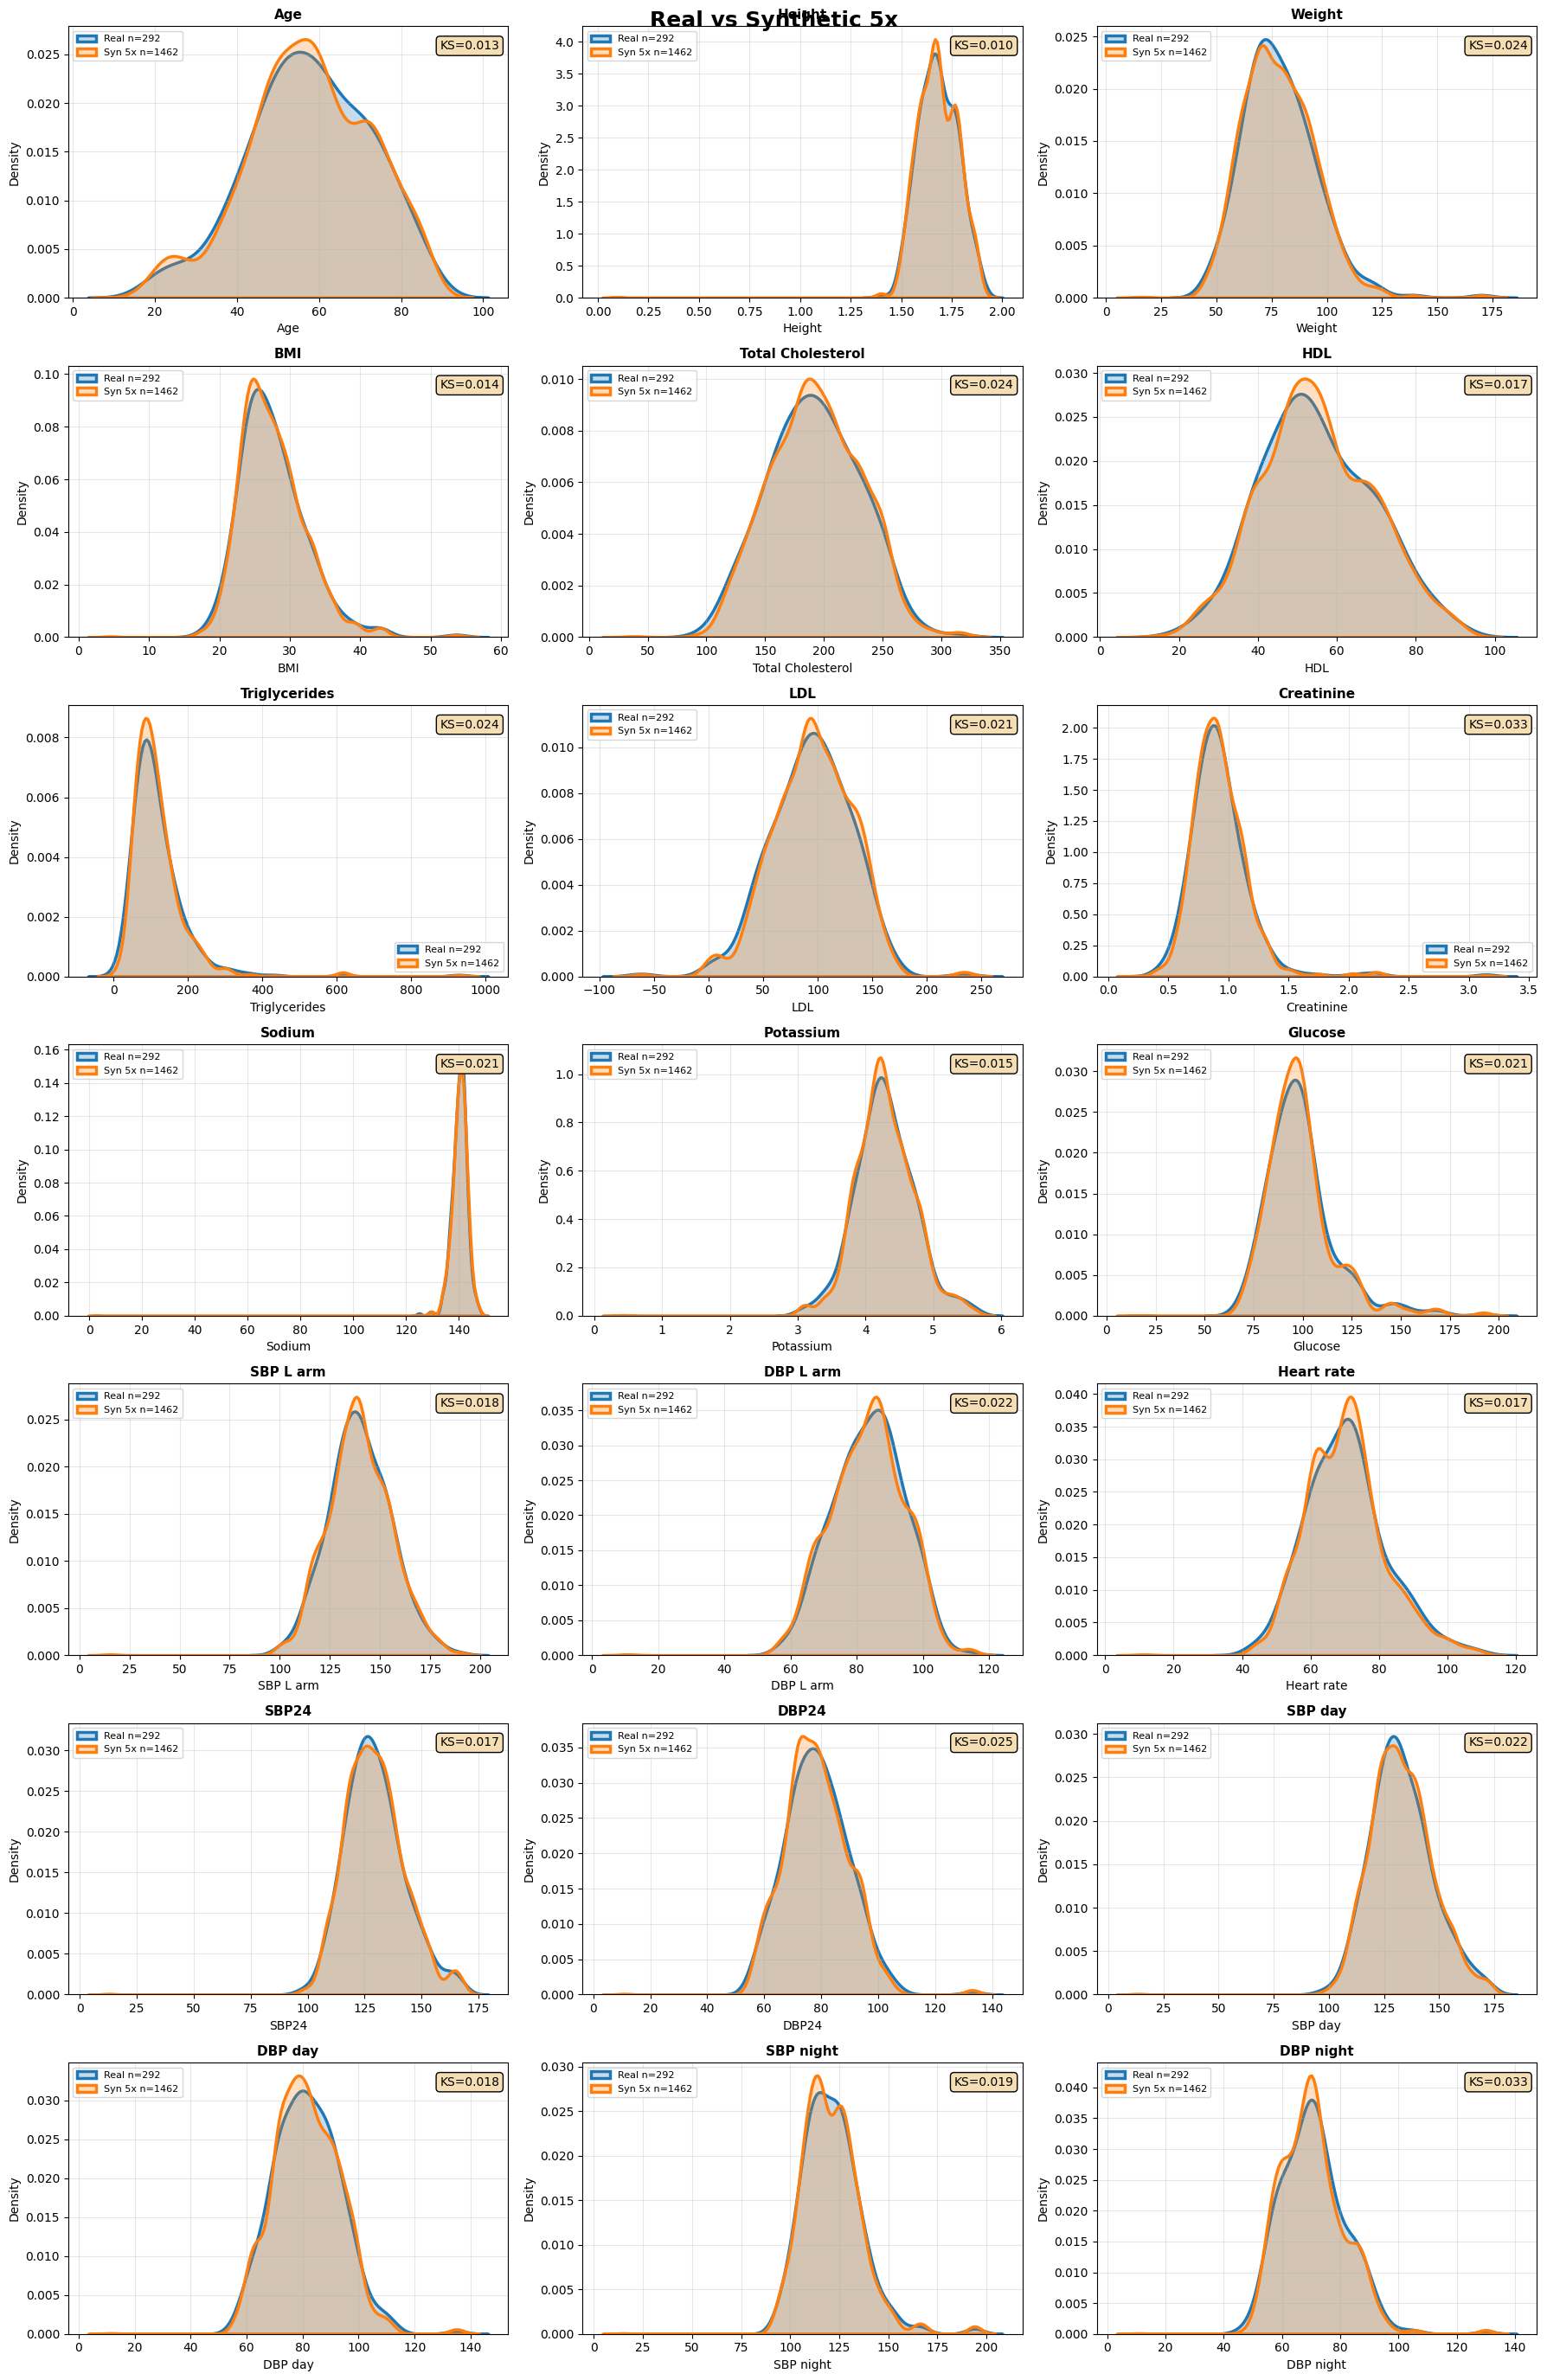

✅ GRIGLIA 3x7: 21 distribuzioni complete!

🔥 21x21 Correlation Matrices...


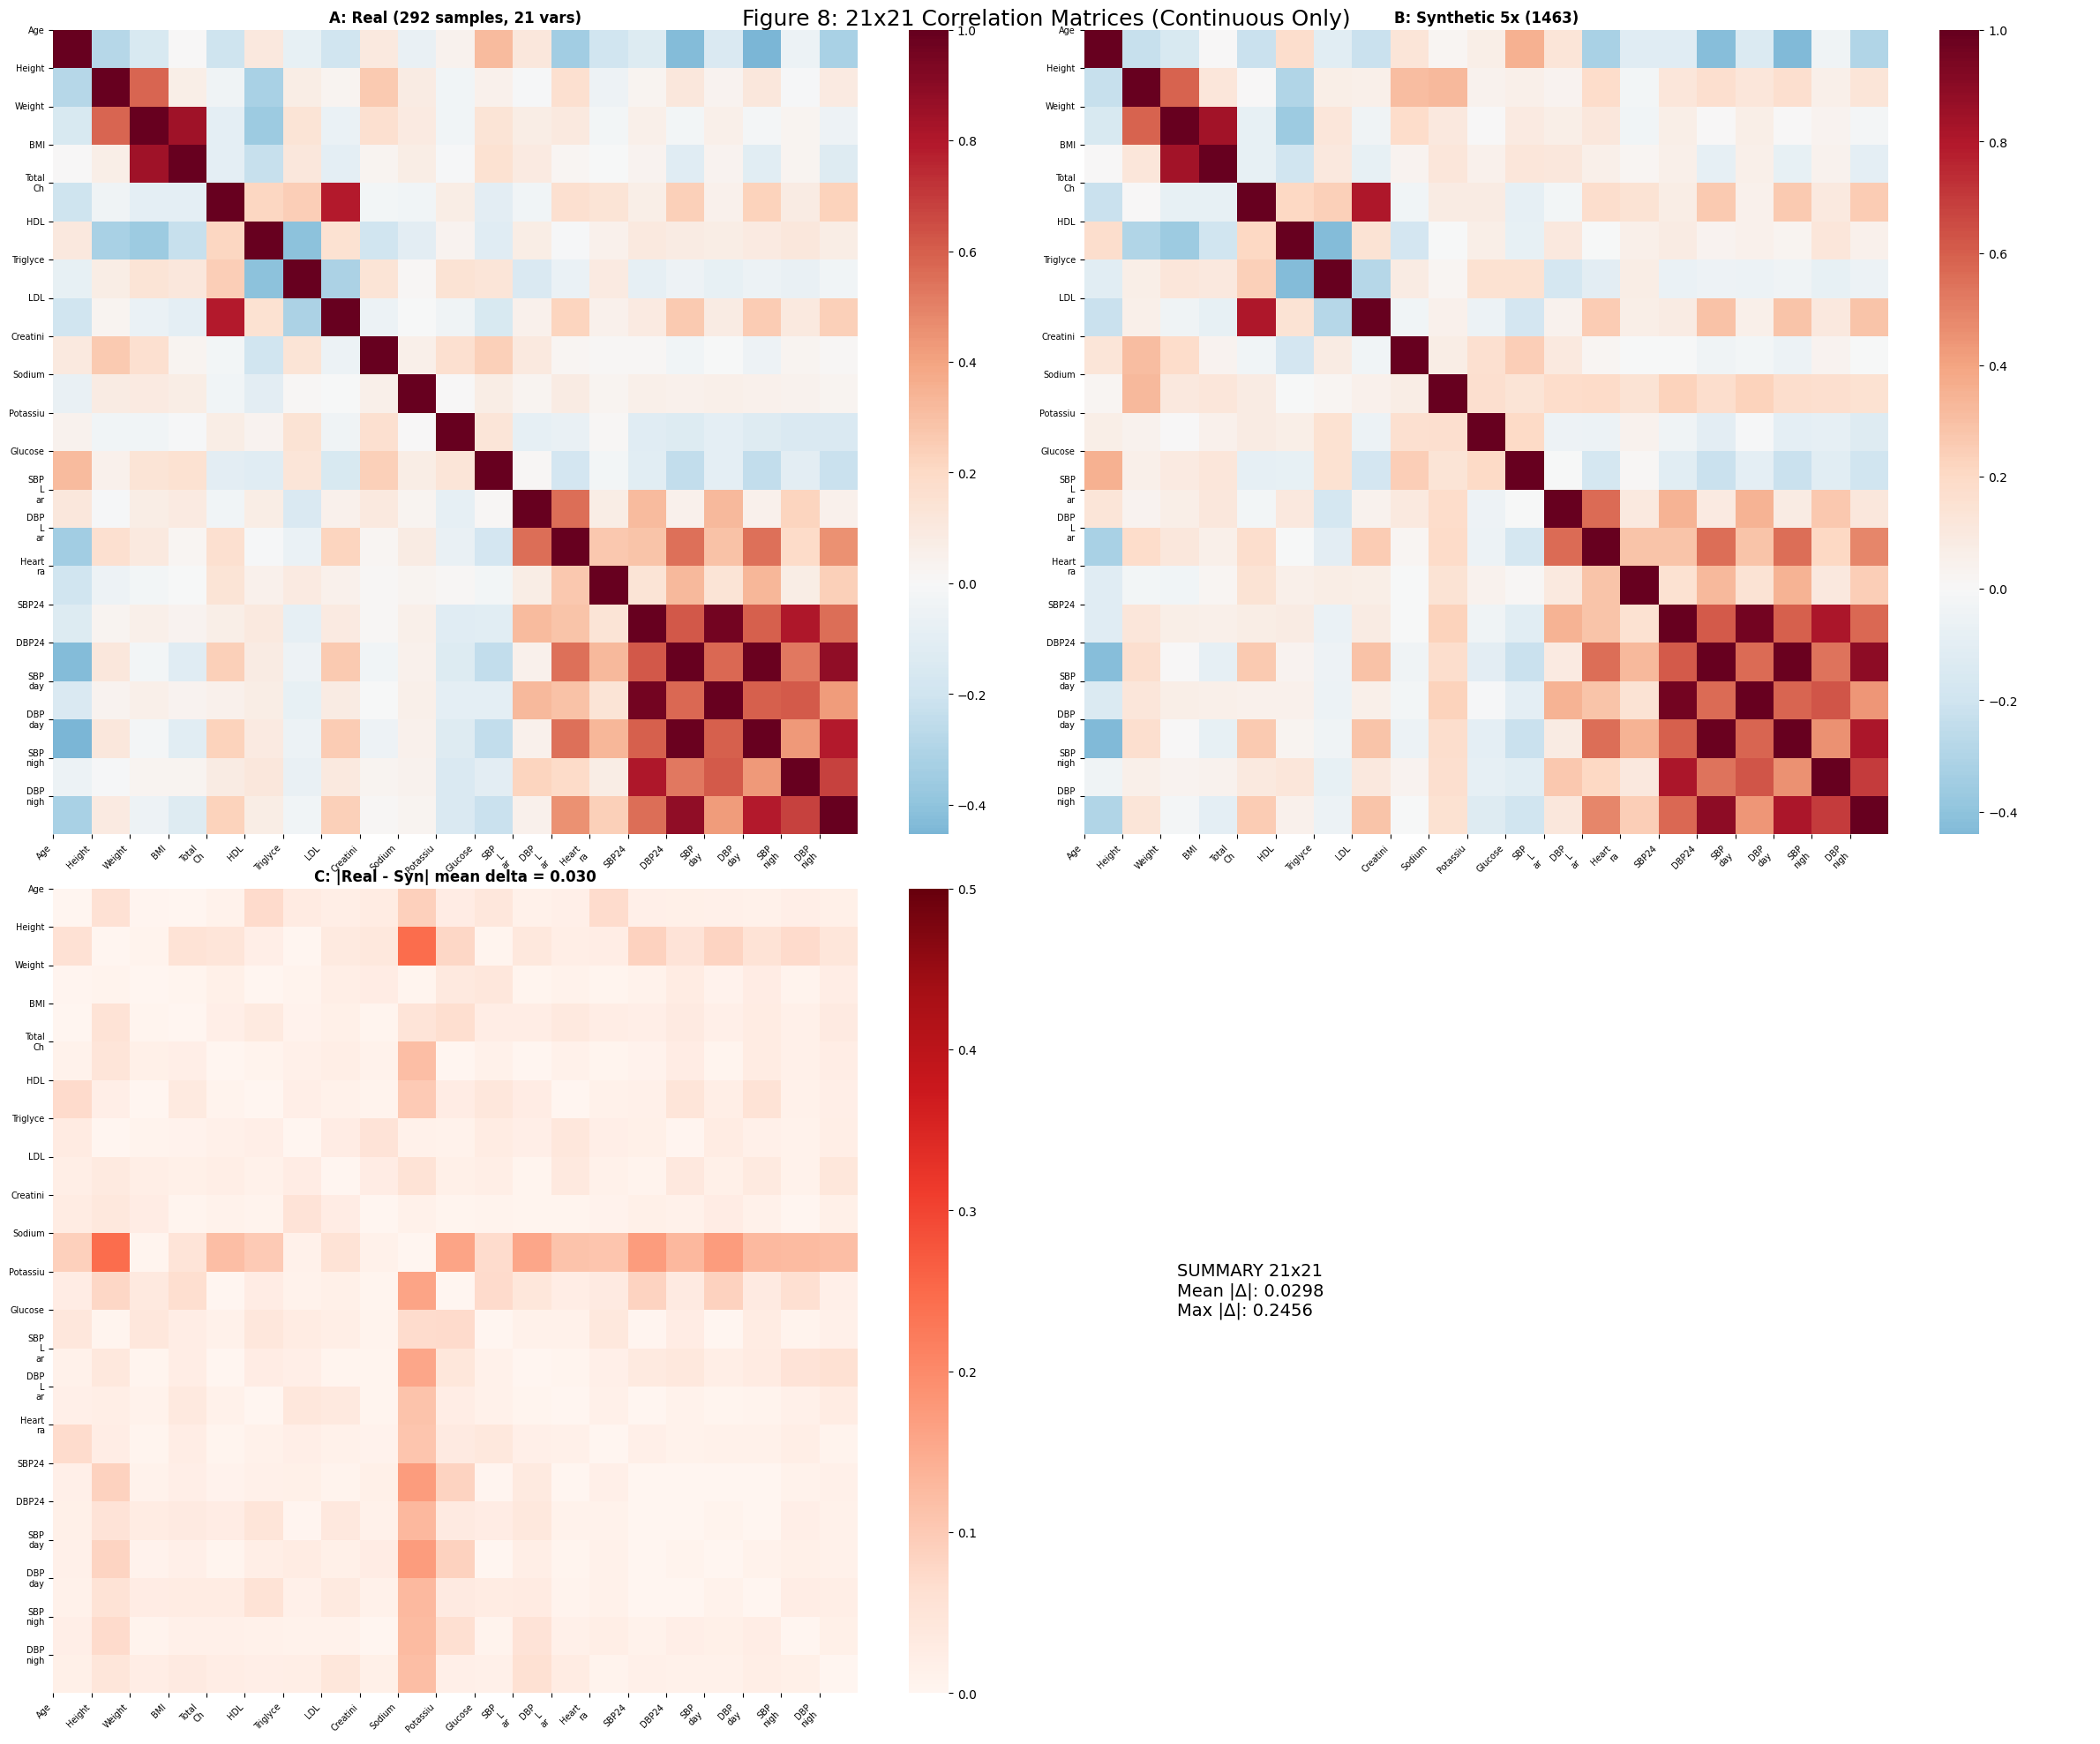

In [18]:

print("21 Continuous Distributions: GRIGLIA 3x7...")

df_real = pd.read_excel("DB_orig_totale.xlsx").drop(columns=["ID"])
cont_cols = df_real.select_dtypes(np.number).columns[df_real.nunique() > 5].tolist()
n_cont = len(cont_cols)

n_rows = (n_cont + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 4*n_rows))
if n_rows == 1: axes = axes.reshape(1,-1)

for i, col in enumerate(cont_cols):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    
    real_data = df_real[col].dropna()
    syn_data = df_syn_5x[col].dropna()
    
    sns.kdeplot(real_data, ax=ax, label=f"Real n={len(real_data)}", 
               fill=True, alpha=0.25, linewidth=2.5, color="#1f77b4")
    sns.kdeplot(syn_data, ax=ax, label=f"Syn 5x n={len(syn_data)}", 
               fill=True, alpha=0.25, linewidth=2.5, color="#ff7f0e")
    
    ax.set_title(f"{col}", fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    if len(real_data) > 3 and len(syn_data) > 3:
        ks_stat, _ = ks_2samp(real_data, syn_data)
        ax.text(0.98, 0.95, "KS=" + "{:.3f}".format(ks_stat), transform=ax.transAxes, 
                ha='right', va='top', bbox=dict(boxstyle="round", facecolor='wheat'))

for i in range(n_cont, len(axes.flat)):
    axes.flat[i].axis('off')

plt.suptitle('Real vs Synthetic 5x', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print(f"GRIGLIA 3x7: {n_cont} distribuzioni complete!")

# === 21x21 CORR (come prima) ===
print("\n21x21 Correlation Matrices...")

corr_real = df_real[cont_cols].corr(method="pearson")
corr_syn = df_syn_5x[cont_cols].corr(method="pearson")
corr_diff = np.abs(corr_real - corr_syn)

mean_delta = corr_diff.values.mean()
max_delta = corr_diff.values.max()

fig, axes = plt.subplots(2, 2, figsize=(24, 20))

sns.heatmap(corr_real, ax=axes[0,0], cmap='RdBu_r', center=0, square=True)
axes[0,0].set_title('A: Real (' + str(len(df_real)) + ' samples, ' + str(n_cont) + ' vars)', fontweight='bold')

sns.heatmap(corr_syn, ax=axes[0,1], cmap='RdBu_r', center=0, square=True)
axes[0,1].set_title('B: Synthetic 5x (' + str(len(df_syn_5x)) + ')', fontweight='bold')

sns.heatmap(corr_diff, ax=axes[1,0], cmap='Reds', vmin=0, vmax=0.5, square=True)
axes[1,0].set_title('C: |Real - Syn| mean delta = ' + "{:.3f}".format(mean_delta), fontweight='bold')

axes[1,1].axis('off')
summary_text = "SUMMARY " + str(n_cont) + "x" + str(n_cont) + "\n" + \
               "Mean |Δ|: " + "{:.4f}".format(mean_delta) + "\n" + \
               "Max |Δ|: " + "{:.4f}".format(max_delta)
axes[1,1].text(0.1, 0.5, summary_text, va='center', fontsize=14)

short_labels = [c.replace(' ', '\n')[:8] for c in cont_cols]
for ax in axes.flat[:3]:
    ax.set_xticks(range(n_cont))
    ax.set_yticks(range(n_cont))
    ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(short_labels, fontsize=7)

plt.suptitle('Figure 8: 21x21 Correlation Matrices (Continuous Only)', fontsize=18)
plt.tight_layout()
plt.show()

📊 21 Continuous Distributions: GRIGLIA 3x7...


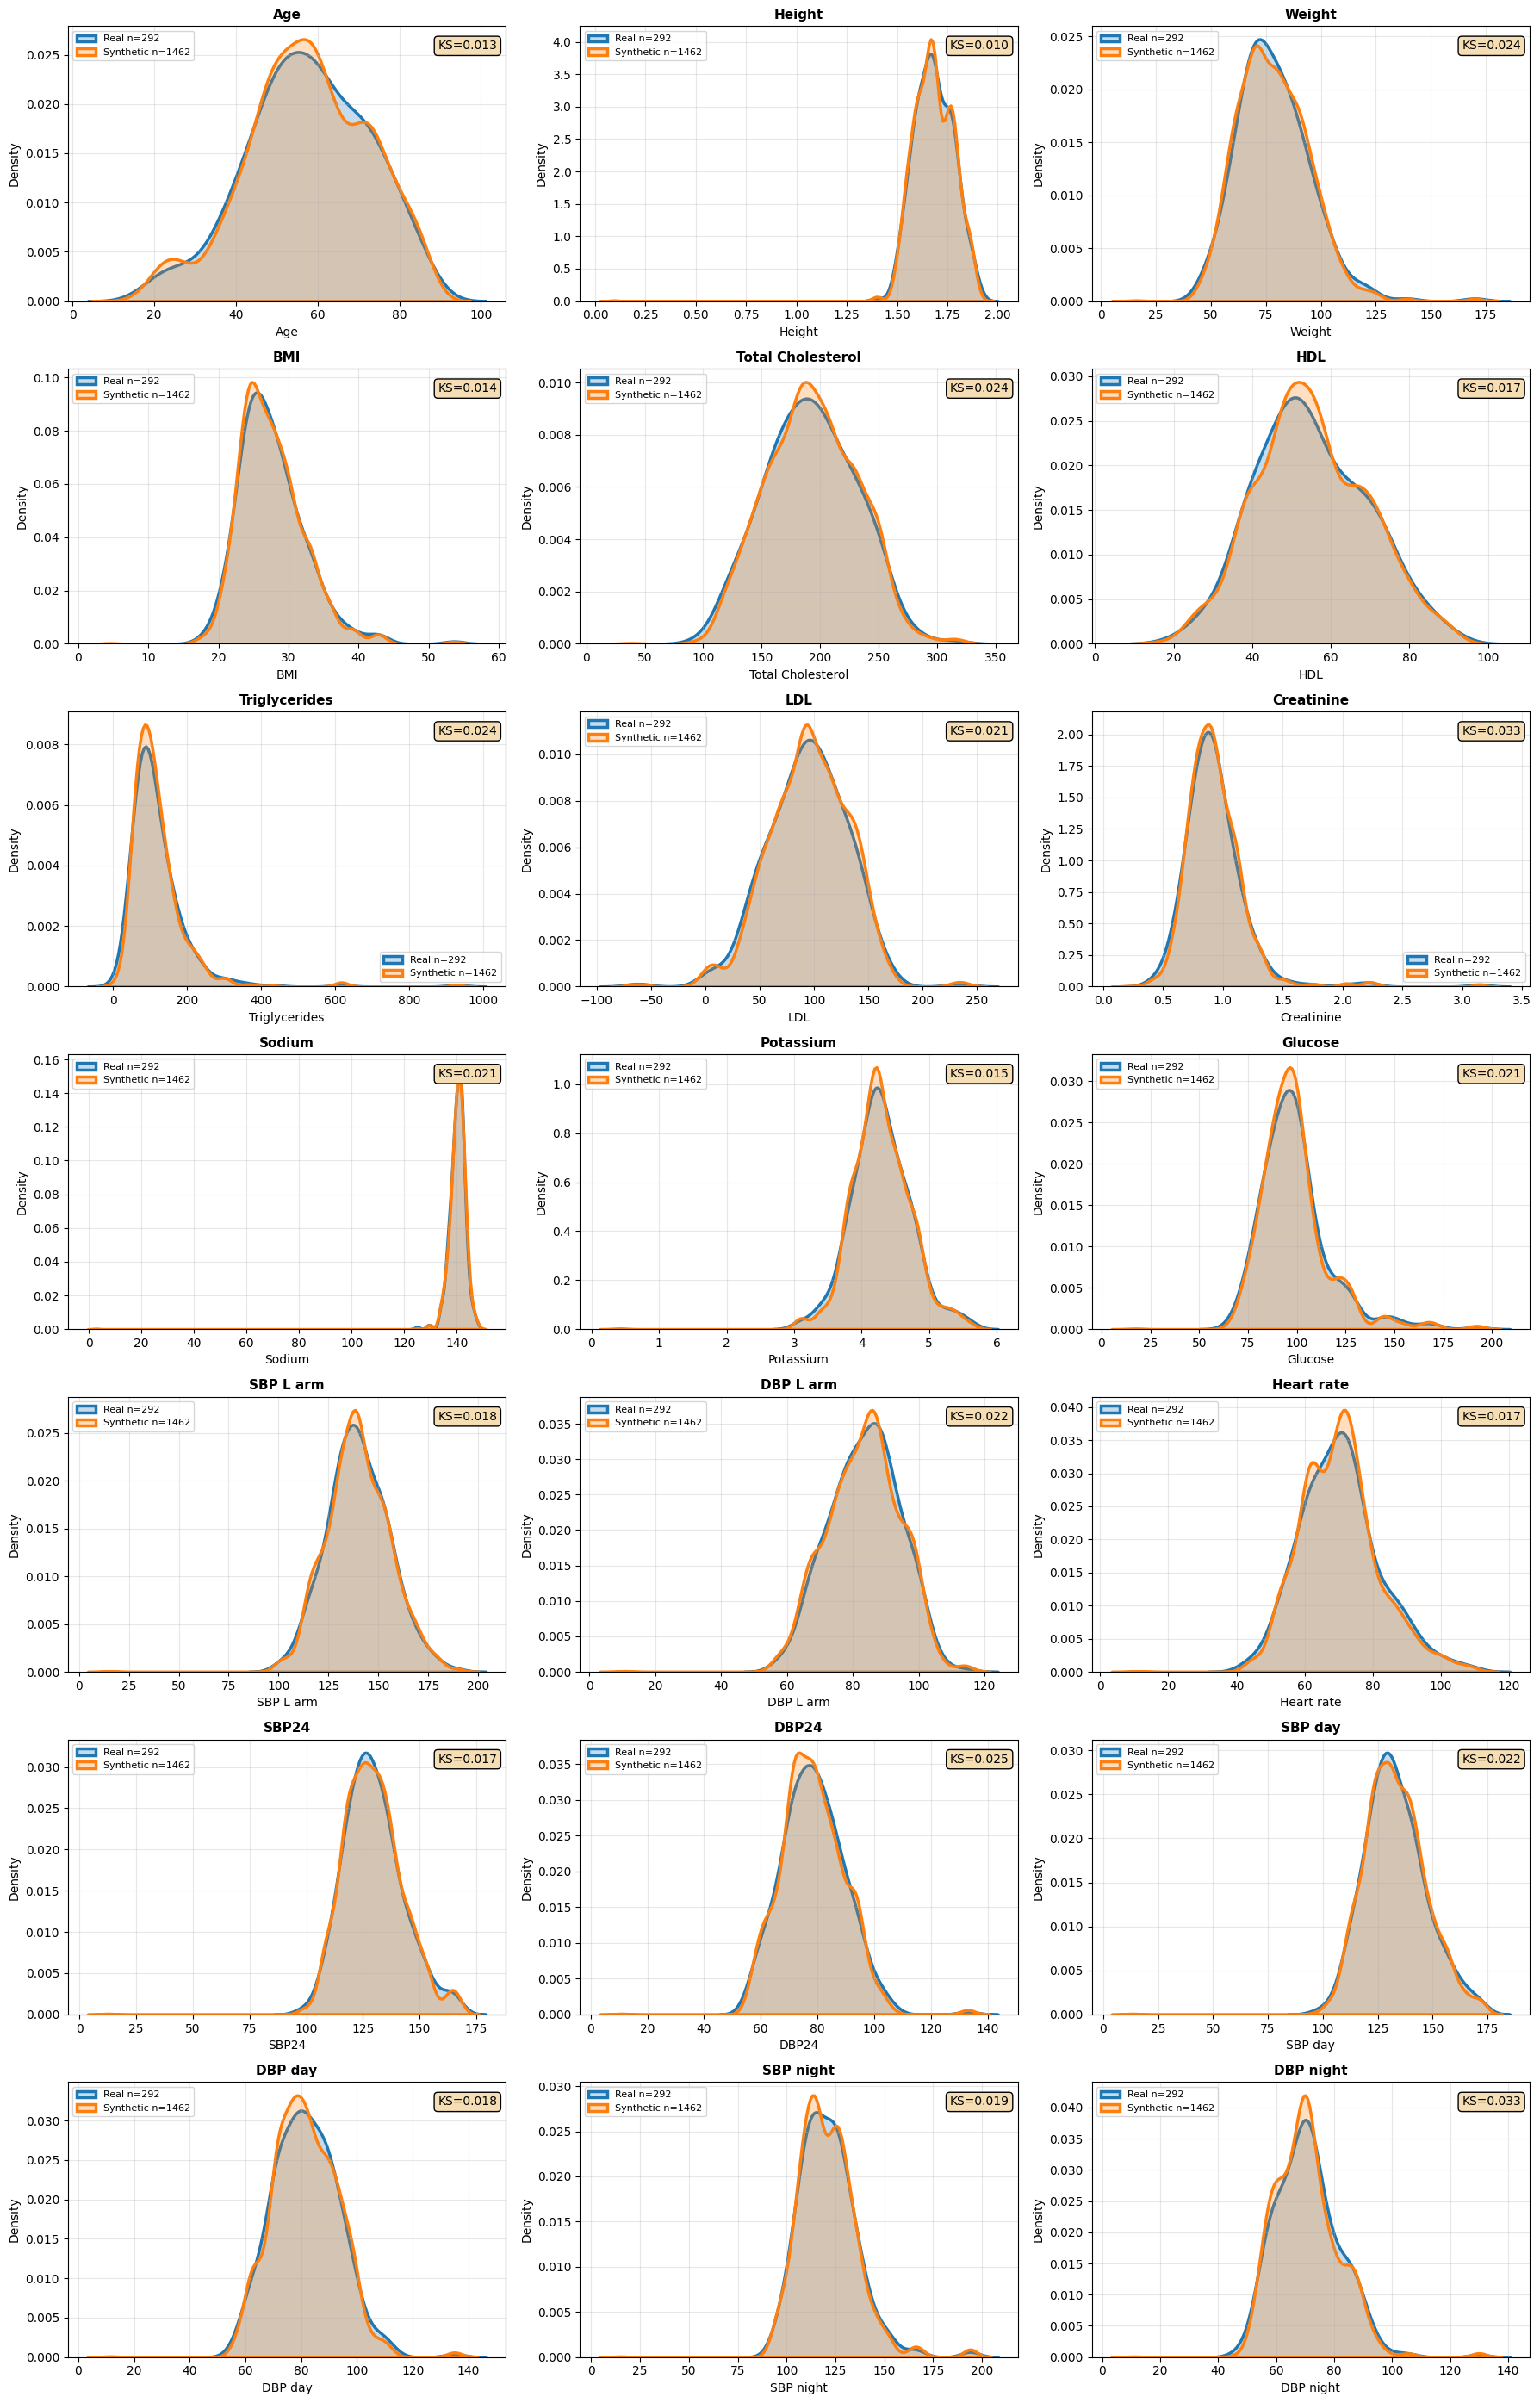

✅ GRIGLIA 3x7: 21 distribuzioni complete!

🔥 21x21 Correlation Matrices...

🔥 21x21 Combined Correlation Matrix...


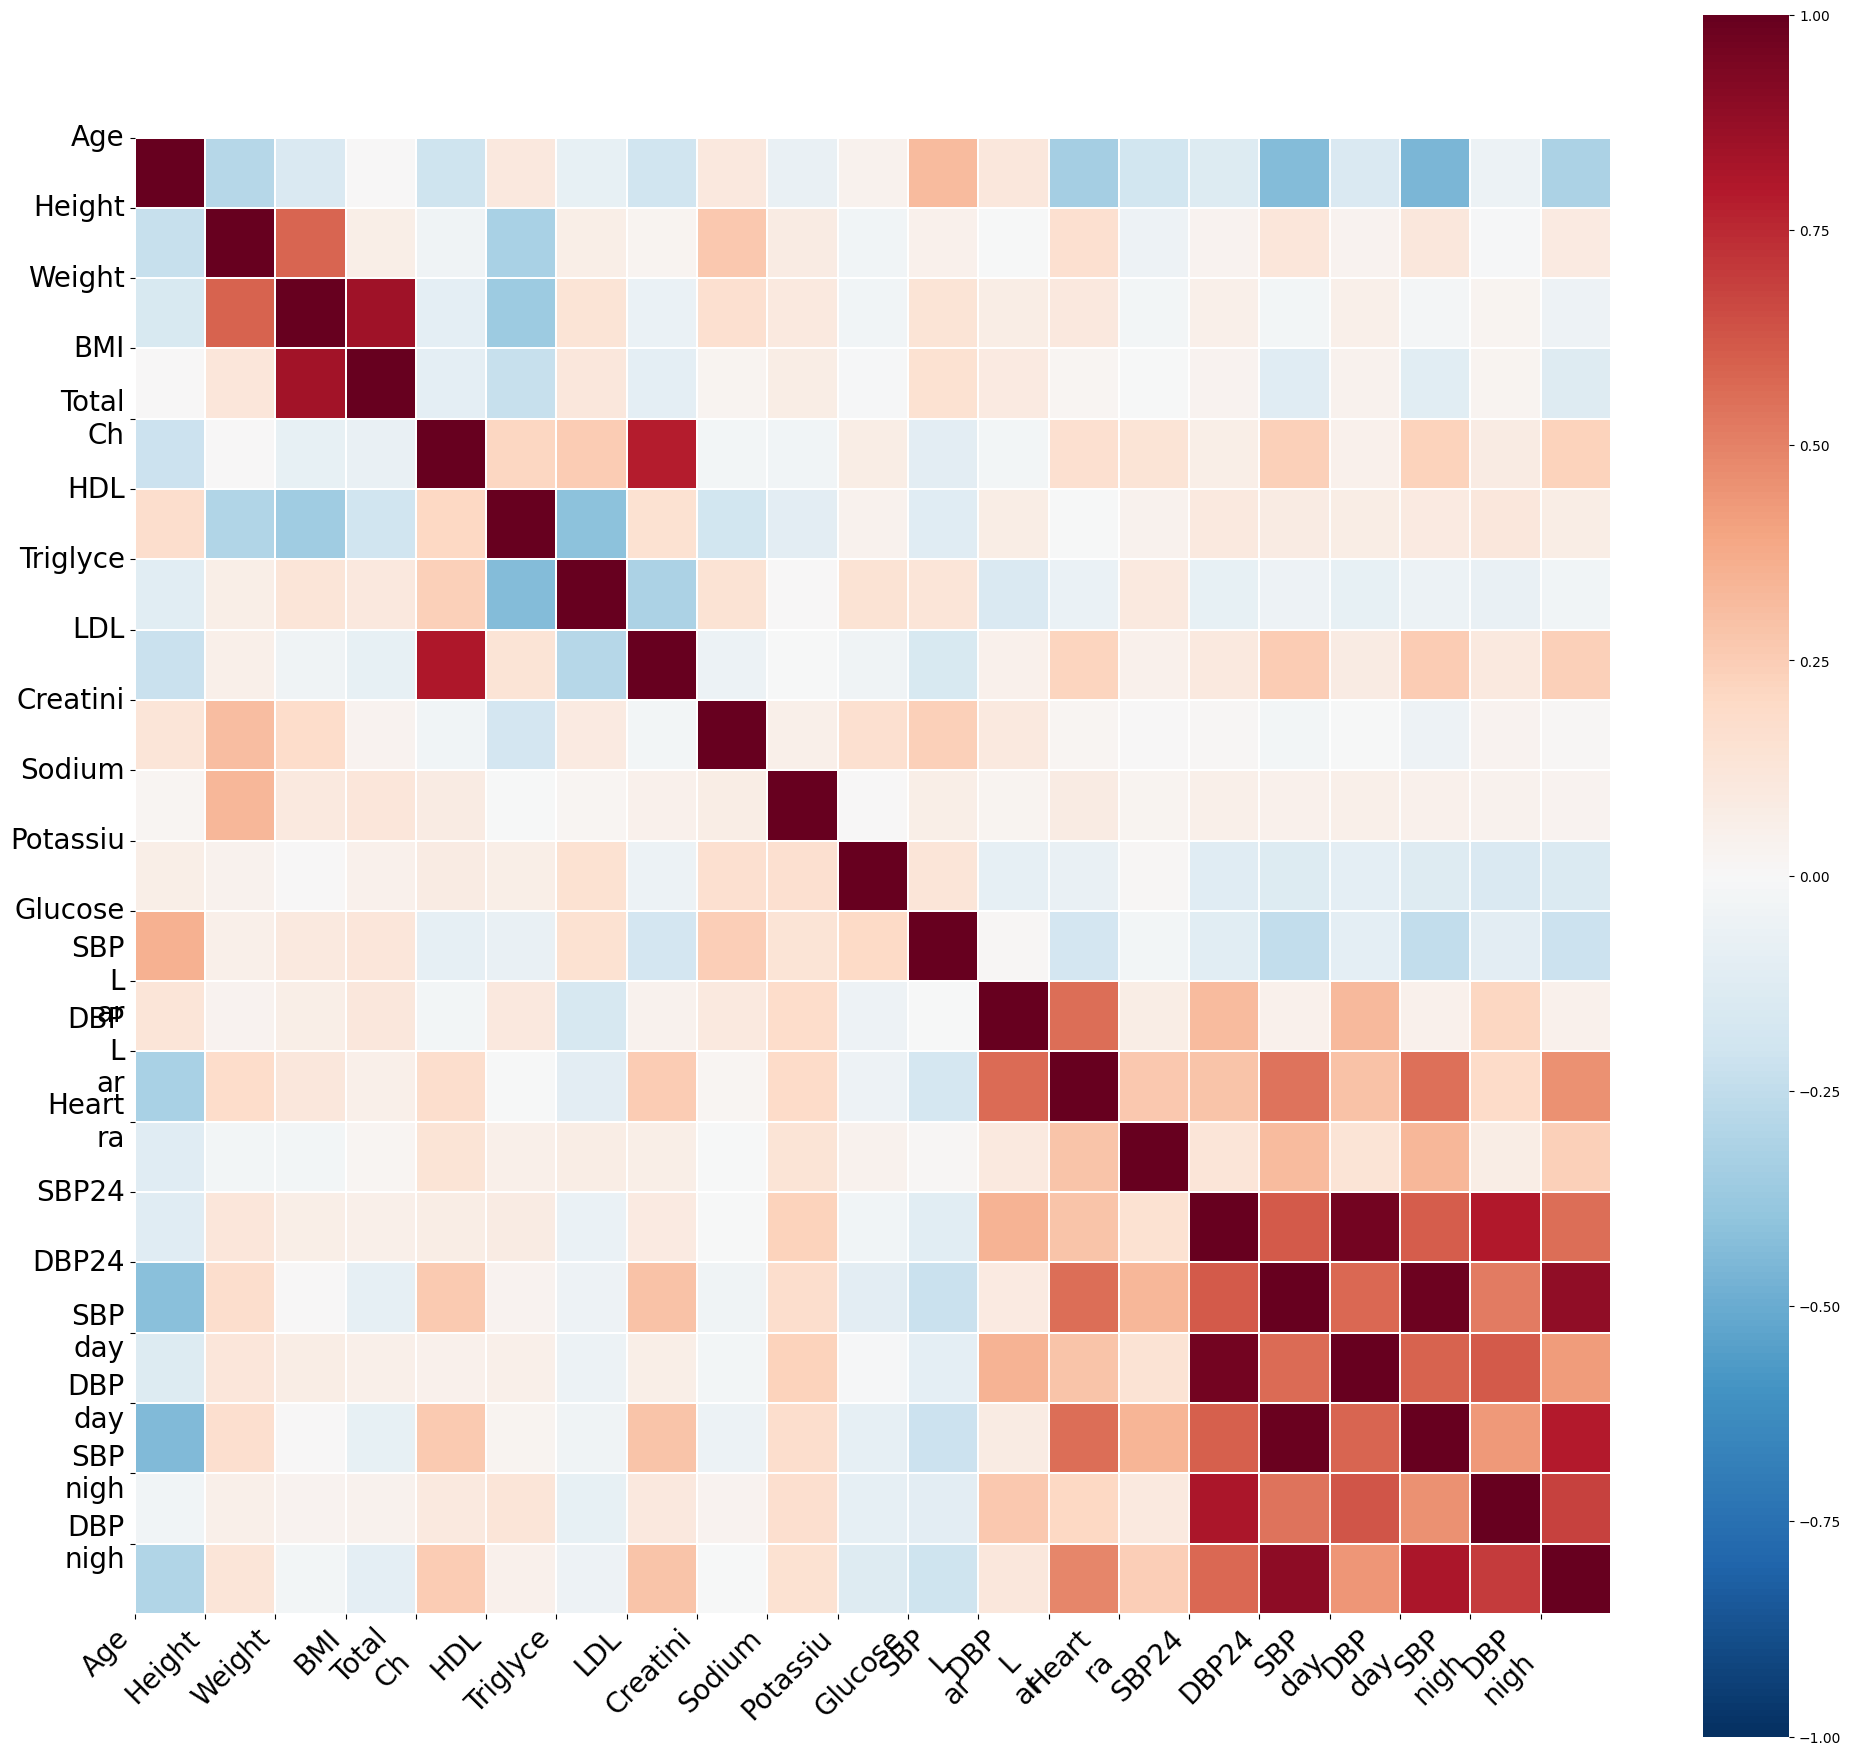

In [19]:
print("21 Continuous Distributions: GRIGLIA 3x7...")

df_real = pd.read_excel("DB_orig_totale.xlsx").drop(columns=["ID"])
cont_cols = df_real.select_dtypes(np.number).columns[df_real.nunique() > 5].tolist()
n_cont = len(cont_cols)

n_rows = (n_cont + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 4*n_rows))
if n_rows == 1: axes = axes.reshape(1,-1)  # Fix 1 riga

for i, col in enumerate(cont_cols):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    
    real_data = df_real[col].dropna()
    syn_data = df_syn_5x[col].dropna()
    
    sns.kdeplot(real_data, ax=ax, label=f"Real n={len(real_data)}", 
               fill=True, alpha=0.25, linewidth=2.5, color="#1f77b4")
    sns.kdeplot(syn_data, ax=ax, label=f"Synthetic n={len(syn_data)}", 
               fill=True, alpha=0.25, linewidth=2.5, color="#ff7f0e")
    
    ax.set_title(f"{col}", fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    if len(real_data) > 3 and len(syn_data) > 3:
        ks_stat, _ = ks_2samp(real_data, syn_data)
        ax.text(0.98, 0.95, "KS=" + "{:.3f}".format(ks_stat), transform=ax.transAxes, 
                ha='right', va='top', bbox=dict(boxstyle="round", facecolor='wheat'))

for i in range(n_cont, len(axes.flat)):
    axes.flat[i].axis('off')


plt.tight_layout()
plt.show()

print(f"✅ GRIGLIA 3x7: {n_cont} distribuzioni complete!")

print("\n🔥 21x21 Correlation Matrices...")

corr_real = df_real[cont_cols].corr(method="pearson")
corr_syn = df_syn_5x[cont_cols].corr(method="pearson")
corr_diff = np.abs(corr_real - corr_syn)

mean_delta = corr_diff.values.mean()
max_delta = corr_diff.values.max()

print("\n🔥 21x21 Combined Correlation Matrix...")

corr_real = df_real[cont_cols].corr(method="pearson")
corr_syn  = df_syn_5x[cont_cols].corr(method="pearson")

real  = corr_real.values
syn   = corr_syn.values
n     = real.shape[0]

upper_mask = np.triu(np.ones((n, n)), k=1)
lower_mask = np.tril(np.ones((n, n)), k=-1)

combined = upper_mask * real + lower_mask * syn

np.fill_diagonal(combined, 1.0)

combined_corr = pd.DataFrame(combined, 
                             index=cont_cols, 
                             columns=cont_cols)

plt.figure(figsize=(20, 18))

sns.heatmap(
    combined_corr,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3
)

short_labels = [c.replace(' ', '\n')[:8] for c in cont_cols]

plt.xticks(range(n), short_labels, rotation=45, ha='right', fontsize=20)
plt.yticks(range(n), short_labels, fontsize=20)

plt.tight_layout()
plt.show()

📊 21 Continuous Distributions: GRID...


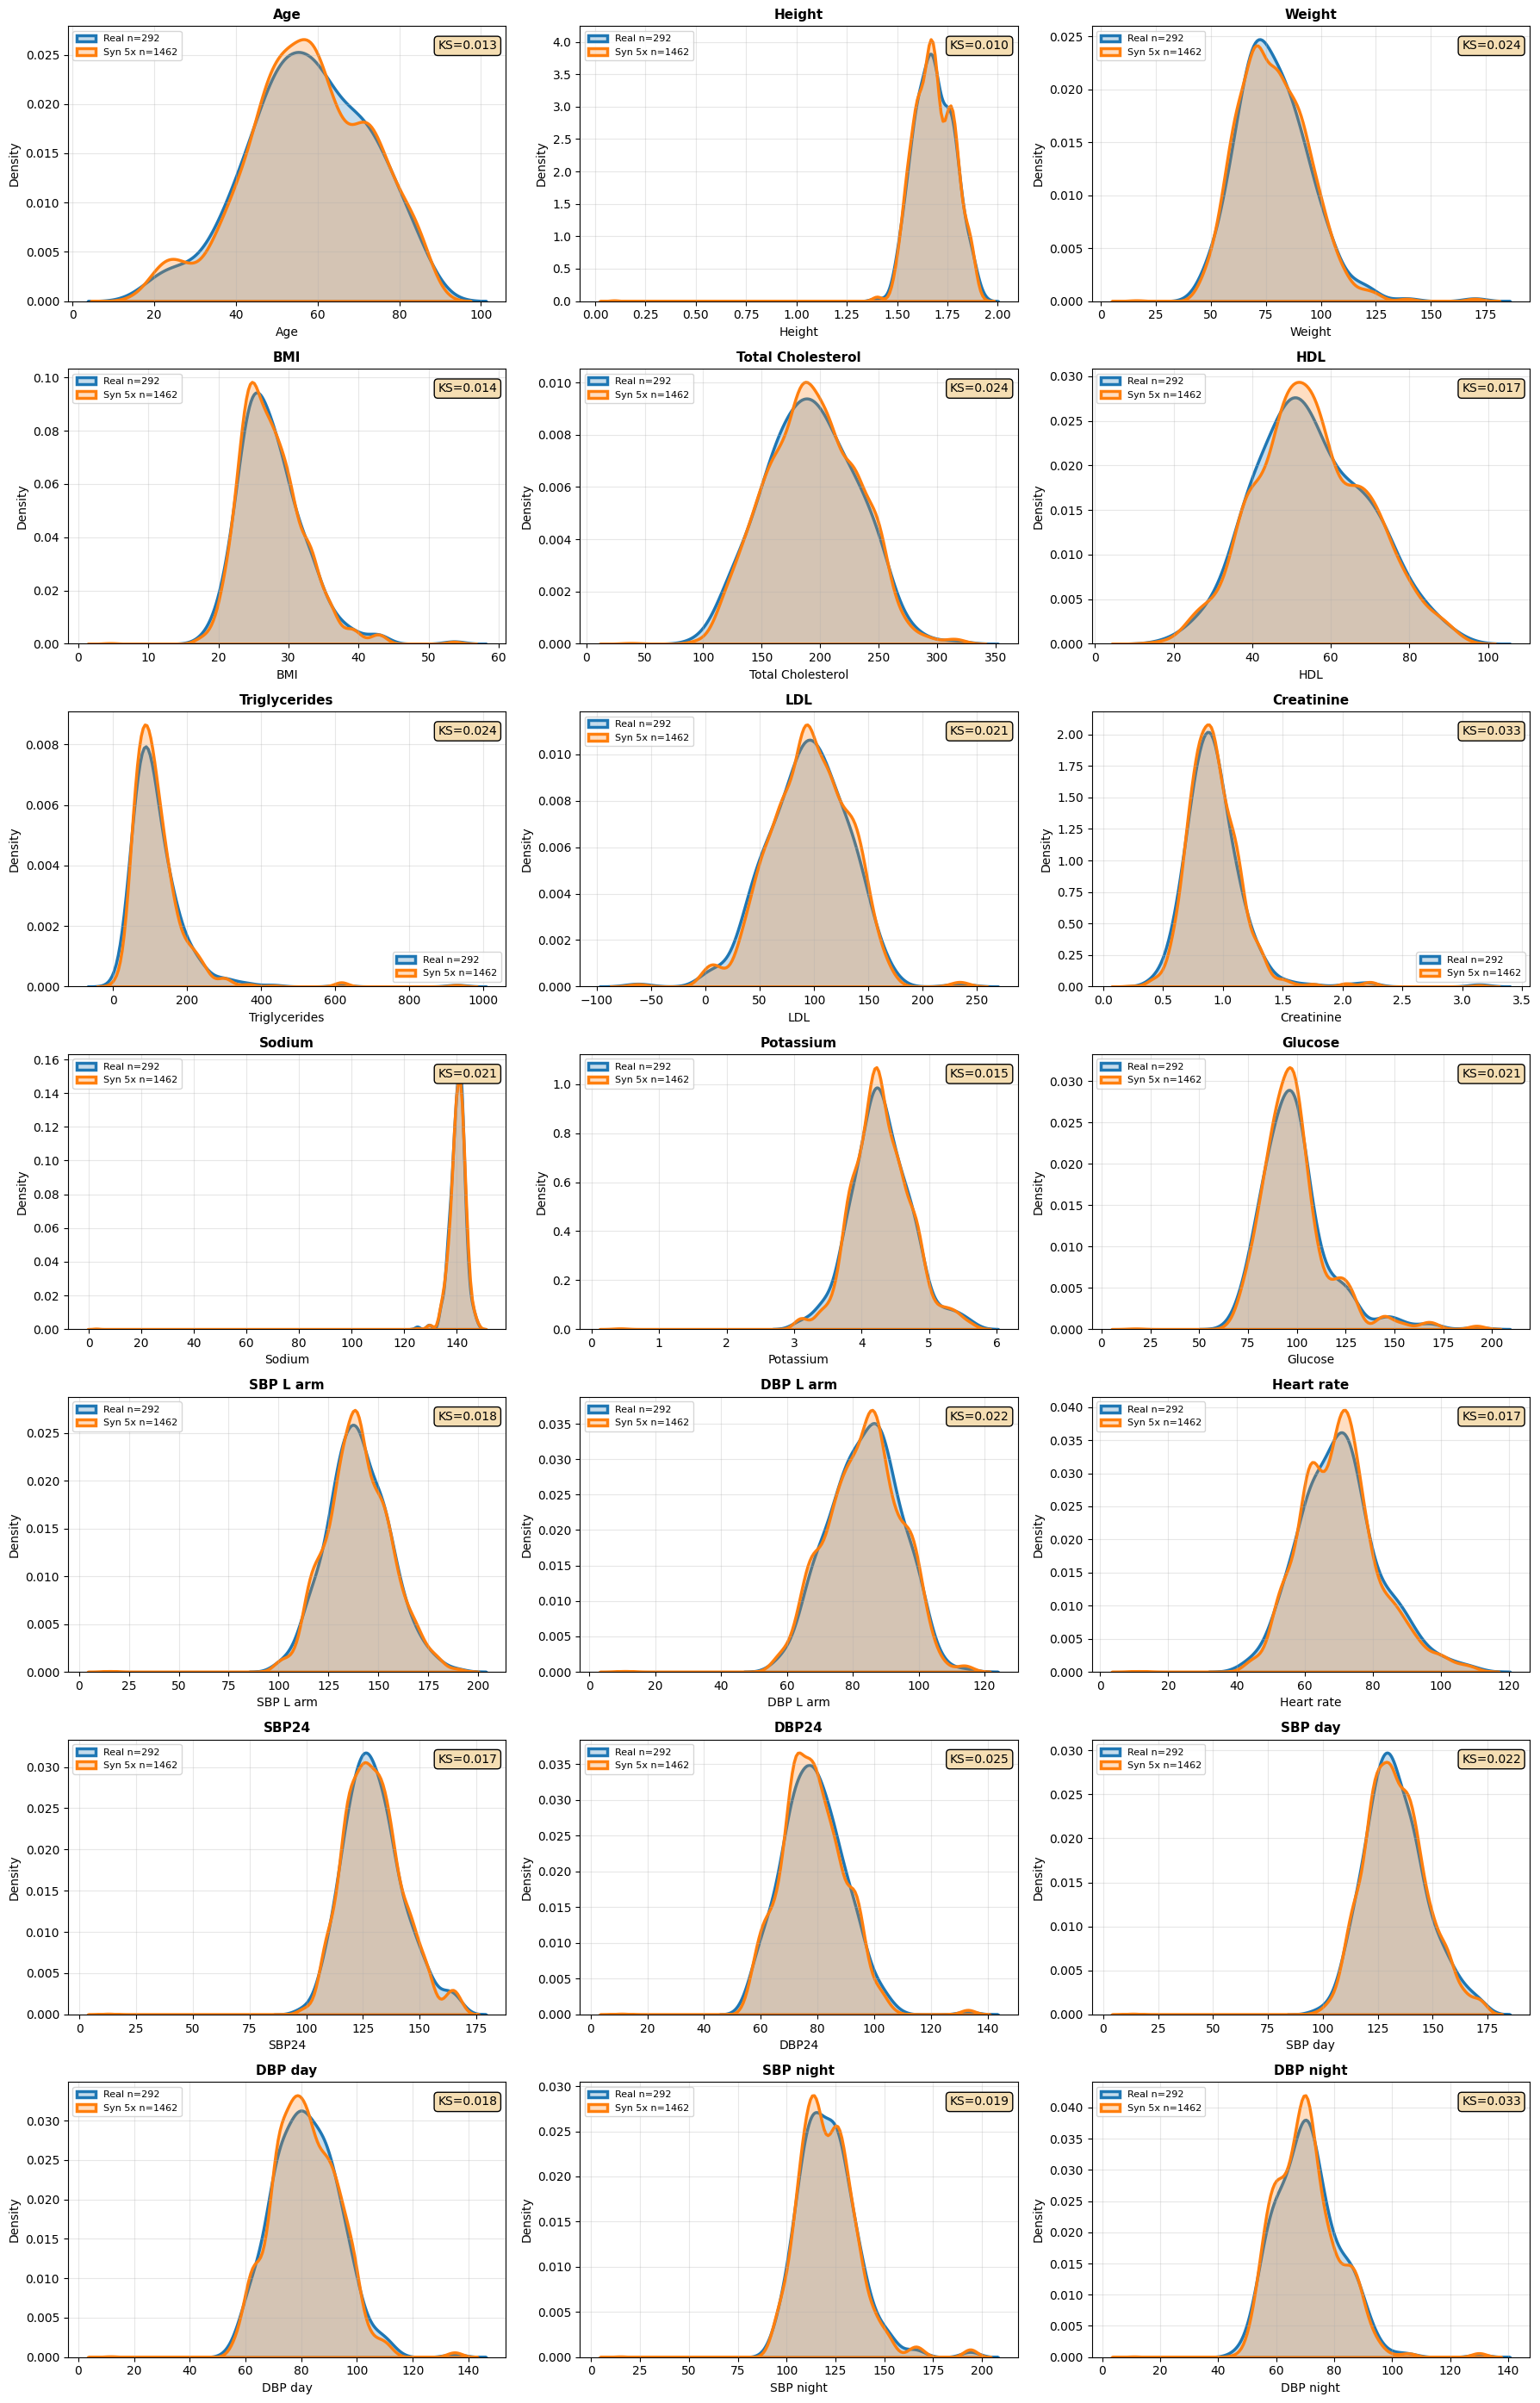

✅ Figure 1 saved.


In [20]:
print("📊 21 Continuous Distributions: GRID...")

df_real = pd.read_excel("DB_orig_totale.xlsx").drop(columns=["ID"])
cont_cols = df_real.select_dtypes(np.number).columns[df_real.nunique() > 5].tolist()
n_cont = len(cont_cols)

n_rows = (n_cont + 2) // 3
fig1, axes = plt.subplots(n_rows, 3, figsize=(18, 4*n_rows))

if n_rows == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(cont_cols):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    
    real_data = df_real[col].dropna()
    syn_data = df_syn_5x[col].dropna()
    
    sns.kdeplot(real_data, ax=ax, fill=True, alpha=0.25,
                linewidth=2.5, color="#1f77b4",
                label=f"Real n={len(real_data)}")
    
    sns.kdeplot(syn_data, ax=ax, fill=True, alpha=0.25,
                linewidth=2.5, color="#ff7f0e",
                label=f"Syn 5x n={len(syn_data)}")
    
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    if len(real_data) > 3 and len(syn_data) > 3:
        ks_stat, _ = ks_2samp(real_data, syn_data)
        ax.text(0.98, 0.95, f"KS={ks_stat:.3f}",
                transform=ax.transAxes,
                ha='right', va='top',
                bbox=dict(boxstyle="round", facecolor='wheat'))

for i in range(n_cont, len(axes.flat)):
    axes.flat[i].axis('off')

plt.tight_layout()
fig1.savefig("Figure1_Distributions.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figure 1 saved.")


🔥 Combined Correlation Matrix...


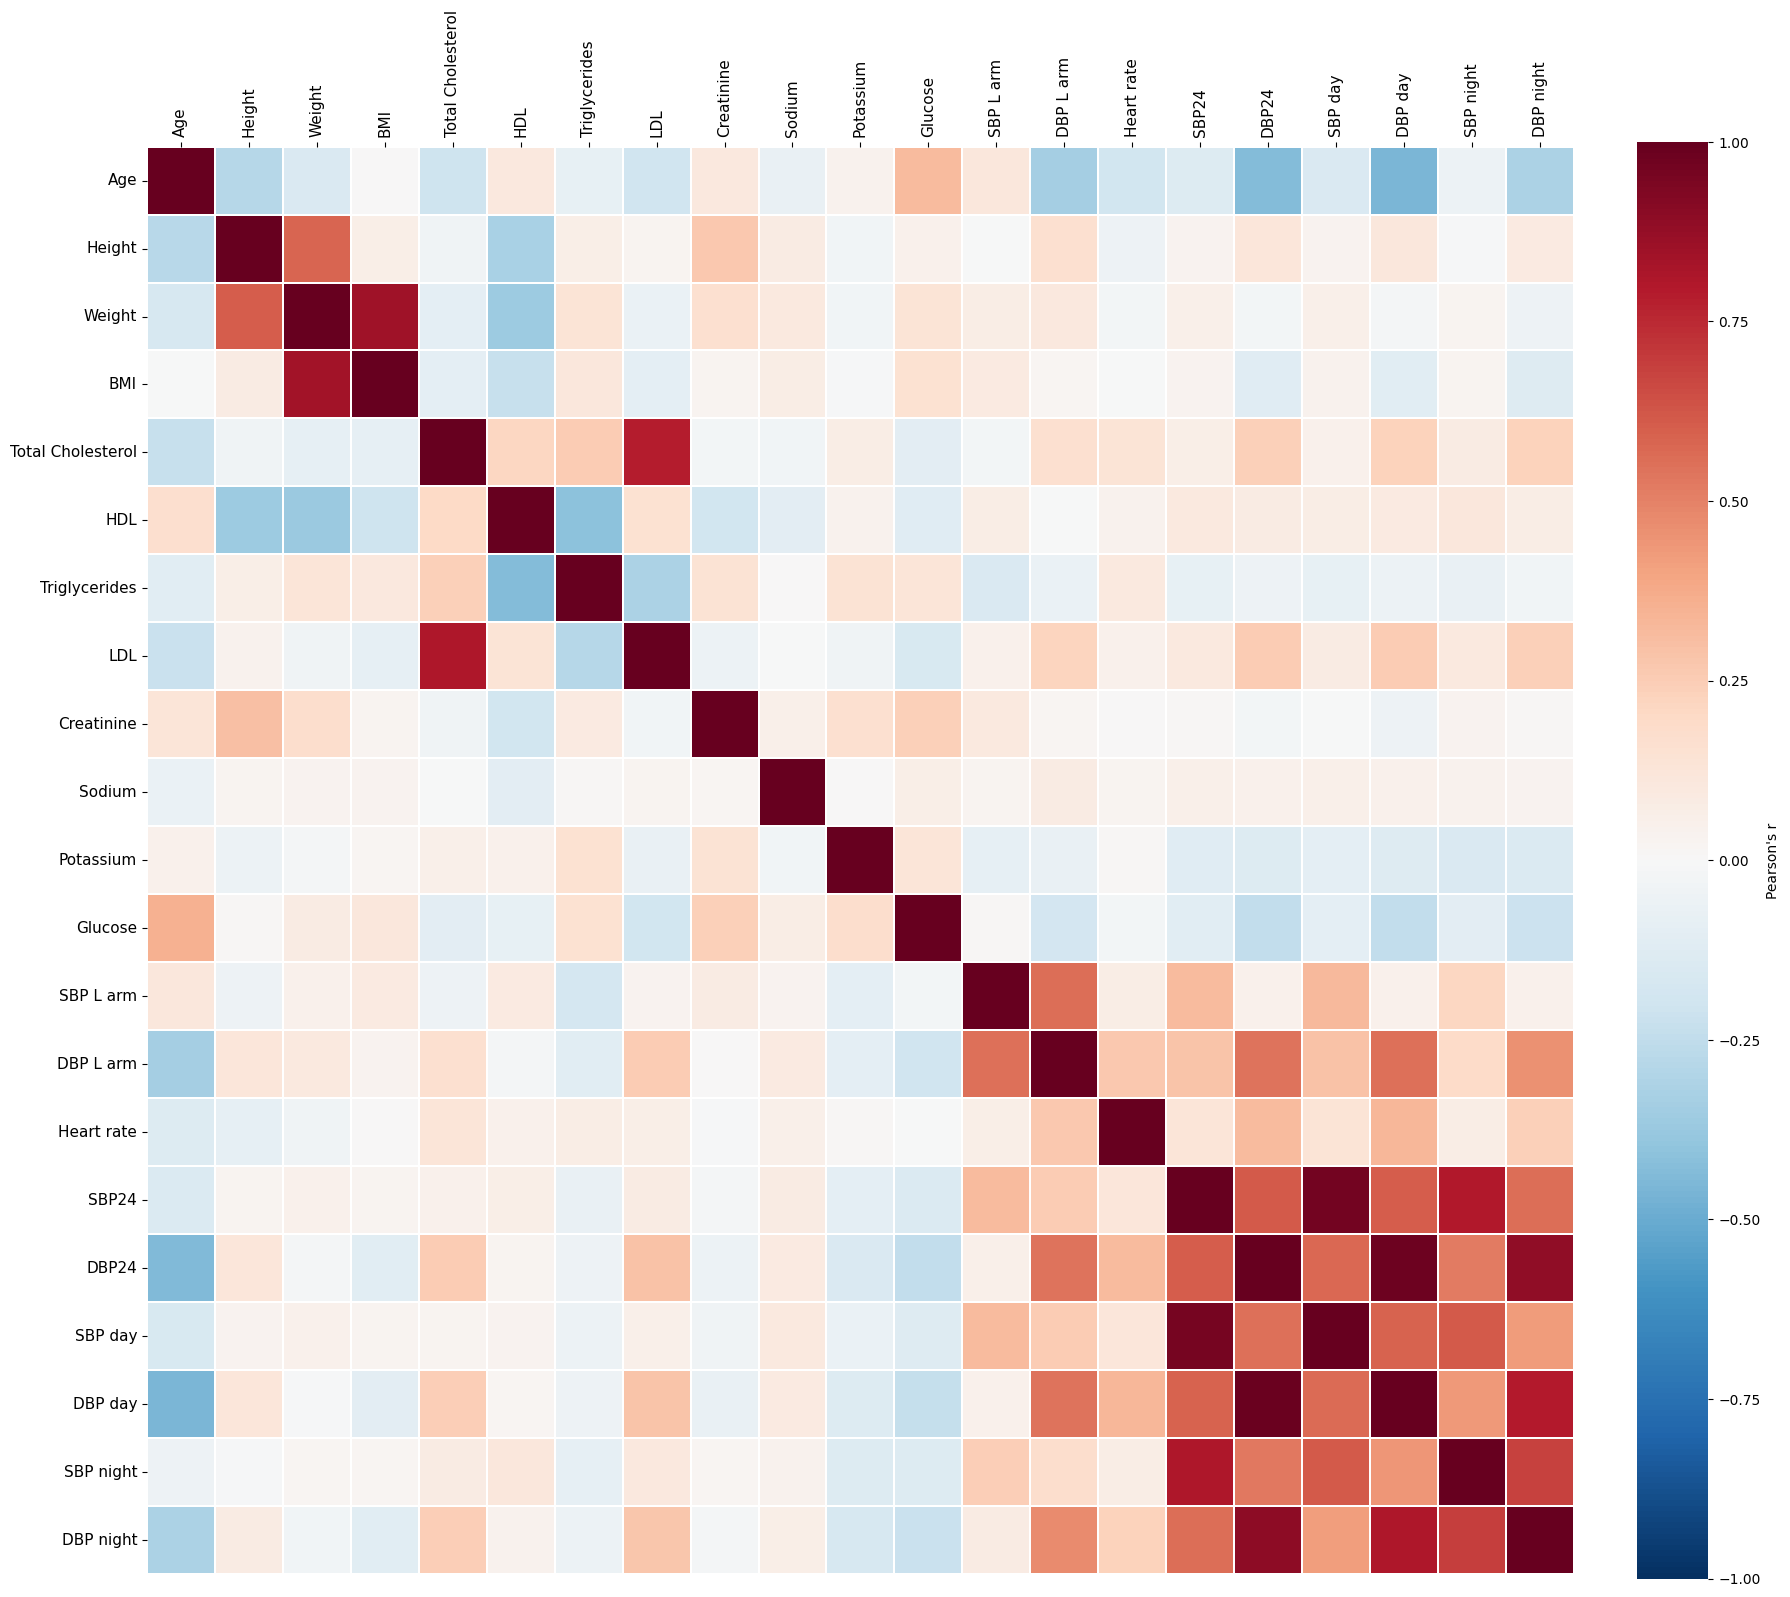

In [45]:
print("\n🔥 Combined Correlation Matrix...")

corr_real = df_real[cont_cols].corr(method="pearson")
corr_syn  = df_syn_5x[cont_cols].corr(method="pearson")

real = corr_real.values
syn  = corr_syn.values
n    = real.shape[0]

upper_mask = np.triu(np.ones((n, n)), k=1)
lower_mask = np.tril(np.ones((n, n)), k=-1)

combined = upper_mask * real + lower_mask * syn
np.fill_diagonal(combined, 1.0)

combined_corr = pd.DataFrame(combined,
                             index=cont_cols,
                             columns=cont_cols)

fig2, ax = plt.subplots(figsize=(18, 18))

sns.heatmap(
    combined_corr,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={
        "label": "Pearson's r",
        "shrink": 1.0,
        "fraction": 0.046,
        "pad": 0.04
    }
)

n = len(cont_cols)

ax.set_xticks(np.arange(n) + 0.5)
ax.set_yticks(np.arange(n) + 0.5)

ax.set_xticklabels(
    cont_cols,
    rotation=90,
    ha="center",
    va="bottom",
    fontsize=11
)

ax.set_yticklabels(
    cont_cols,
    rotation=0,
    fontsize=11
)

ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()

fig2.savefig(
    "Figure2_CombinedCorrelation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

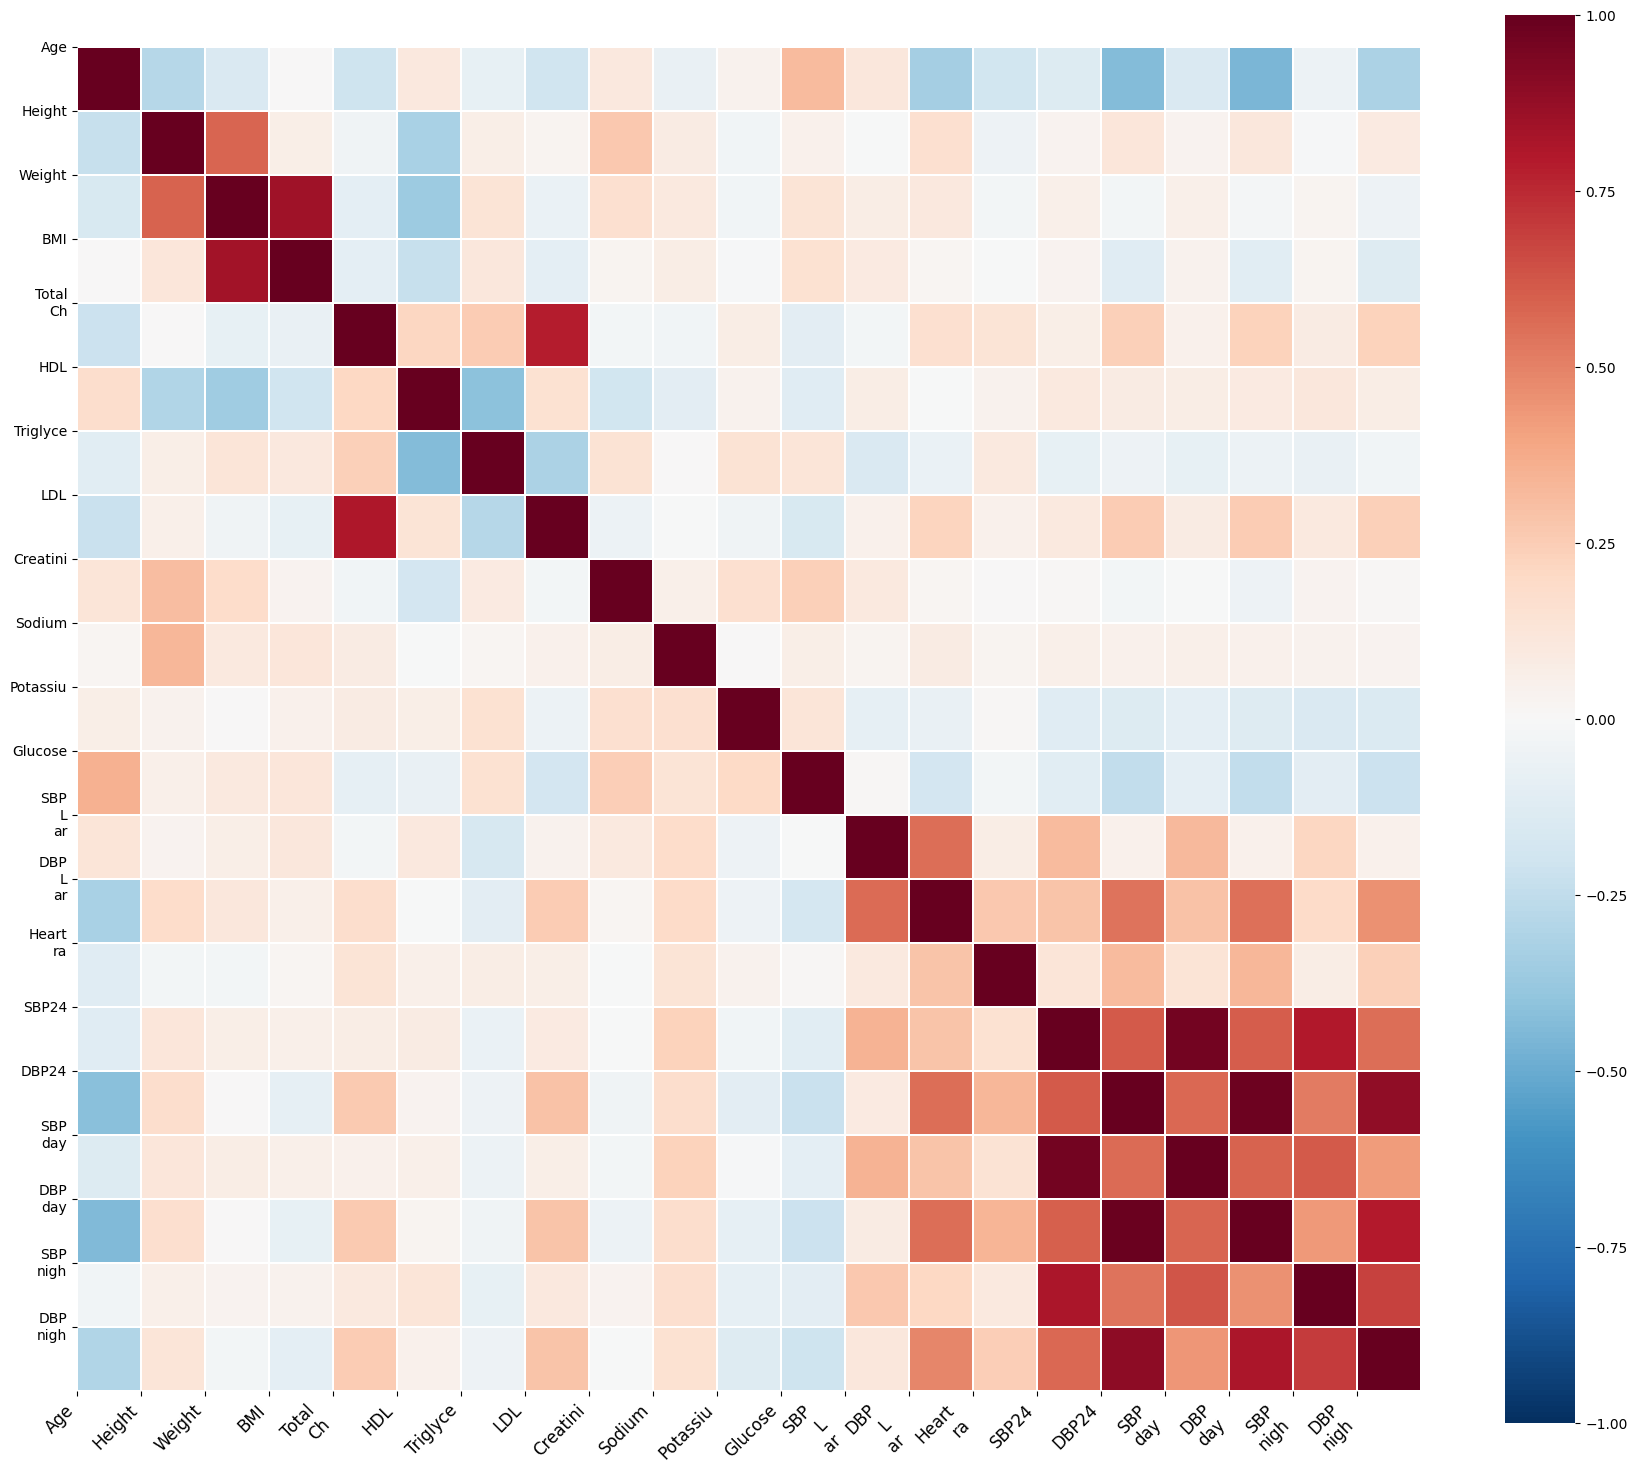

In [22]:
fig2 = plt.figure(figsize=(24, 22))

ax = sns.heatmap(
    combined_corr,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)

short_labels = [c.replace(' ', '\n')[:8] for c in cont_cols]

plt.xticks(range(n), short_labels, rotation=45, ha='right', fontsize=12)
plt.yticks(range(n), short_labels, fontsize=10)

plt.subplots_adjust(left=0.25, bottom=0.1, right=0.95, top=0.9)

fig2.savefig("Figure2_CombinedCorrelation.png",
             dpi=300,
             bbox_inches='tight')

plt.show()


🔥 Correlation Difference Matrix...
Median |Δr|: 0.0204
Mean   |Δr|: 0.0312
Max    |Δr|: 0.2456


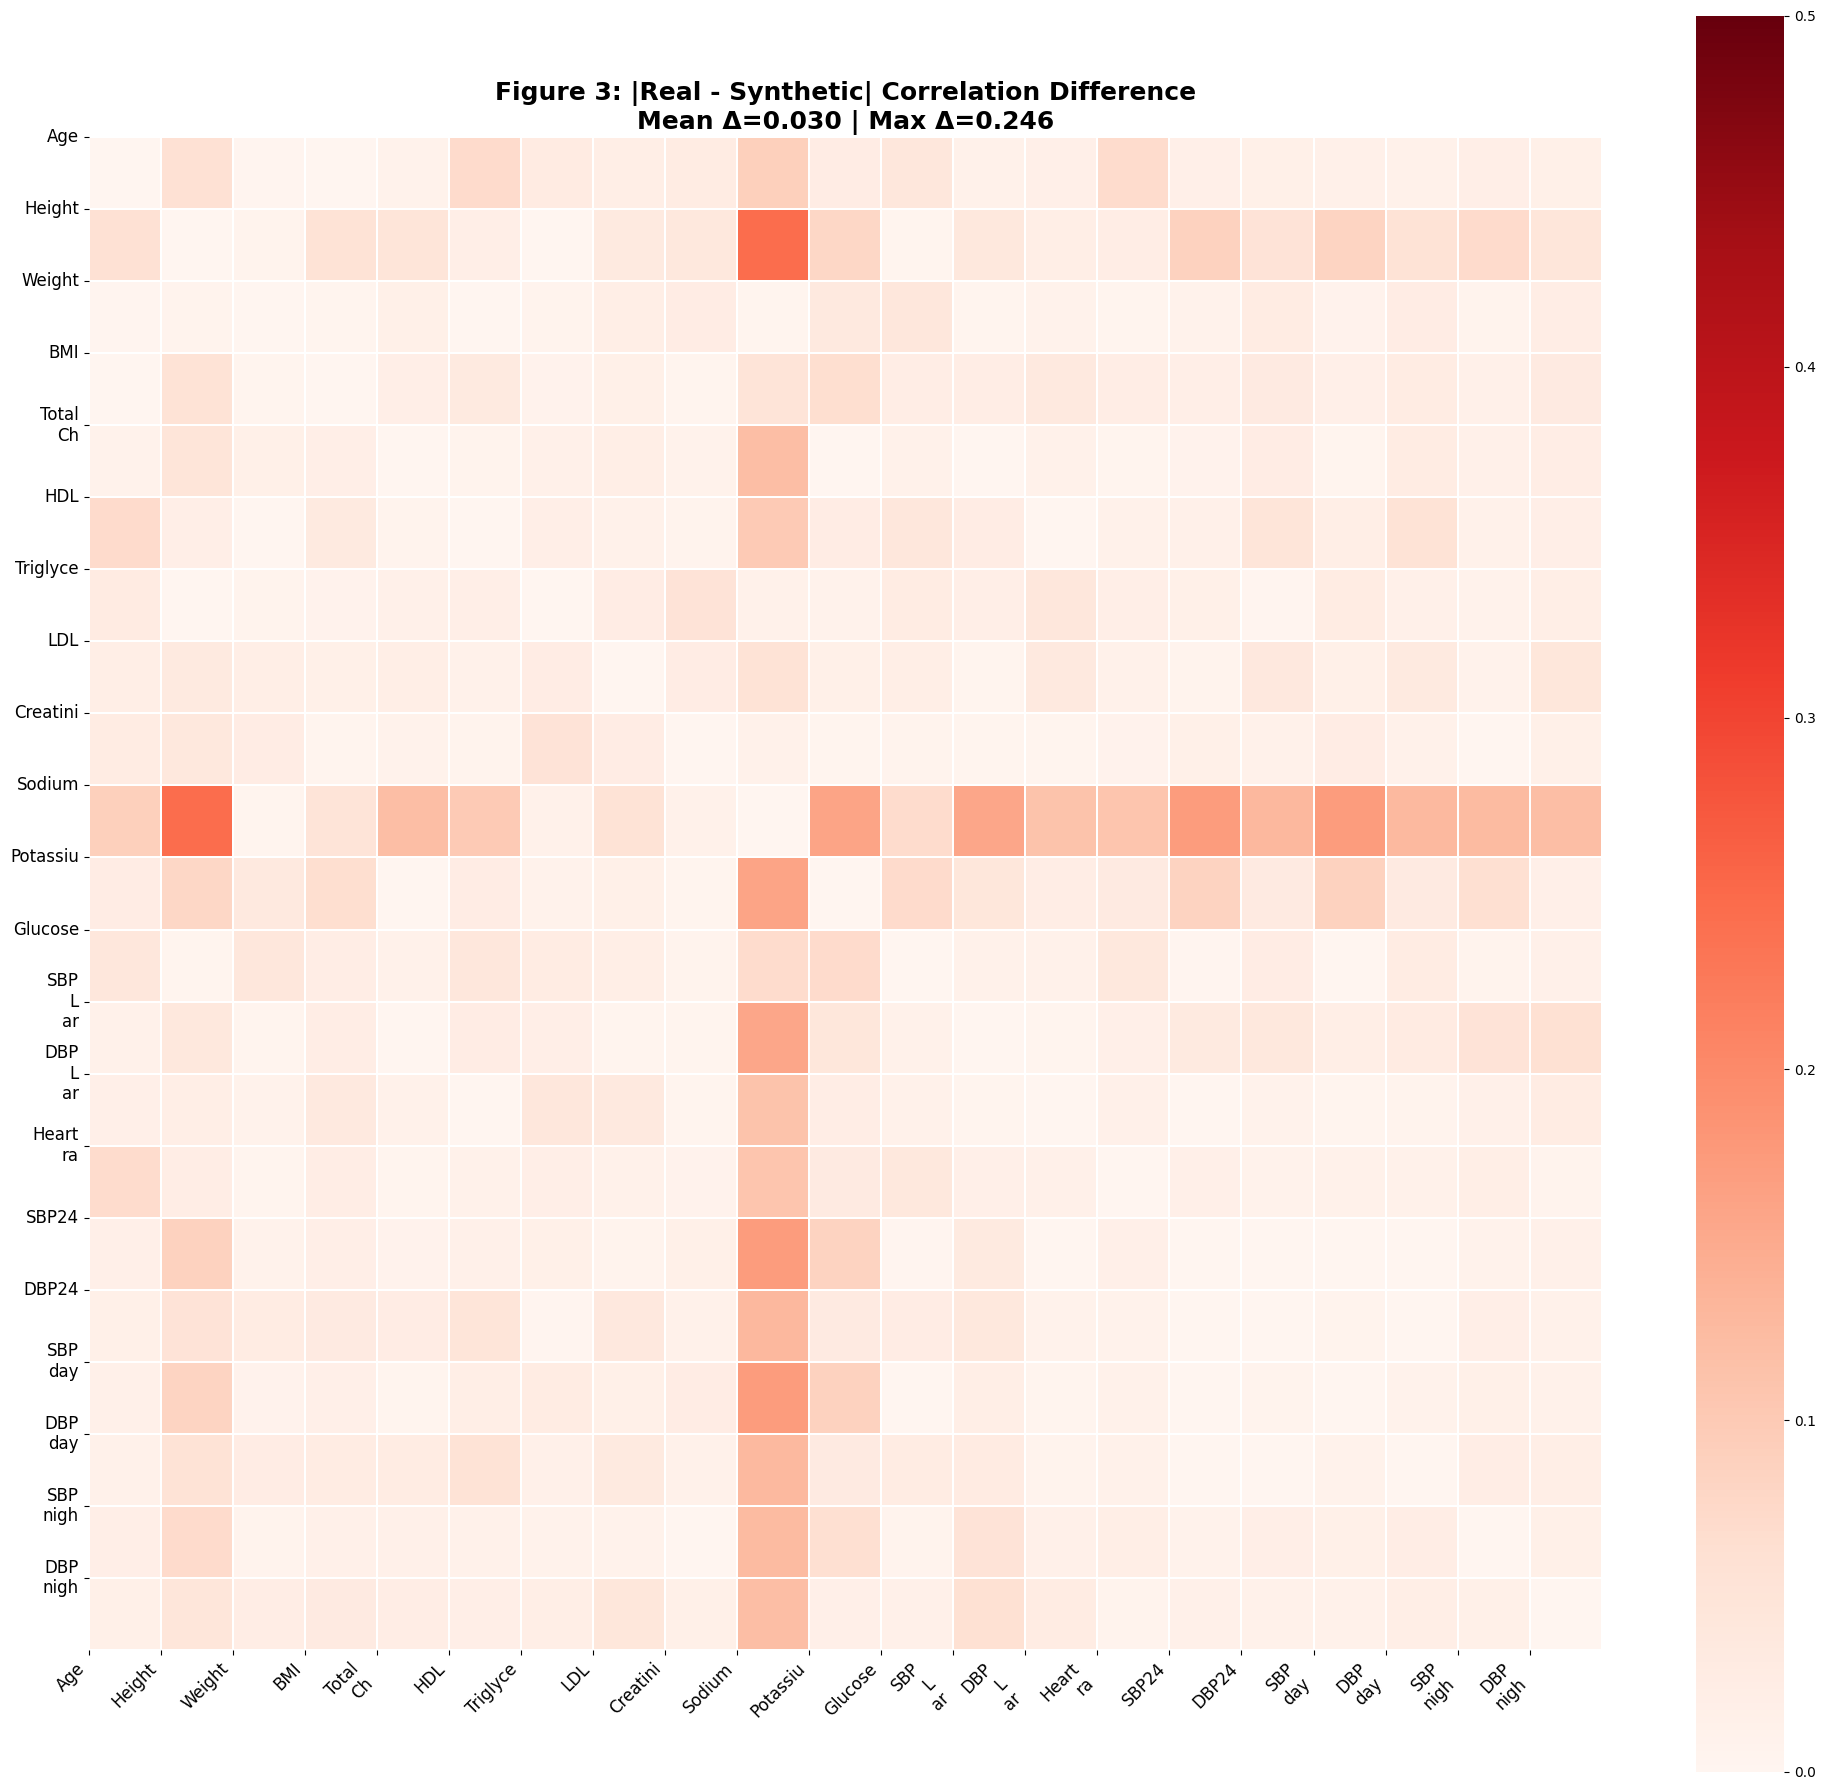

✅ Figure 3 saved.


In [23]:
print("\n🔥 Correlation Difference Matrix...")

corr_diff = np.abs(corr_real - corr_syn)

corr_diff = np.abs(corr_real - corr_syn)

upper = np.triu_indices_from(corr_diff, k=1)

median_delta_r = np.median(corr_diff.values[upper])
mean_delta_r   = np.mean(corr_diff.values[upper])
max_delta_r    = np.max(corr_diff.values[upper])

print(f"Median |Δr|: {median_delta_r:.4f}")
print(f"Mean   |Δr|: {mean_delta_r:.4f}")
print(f"Max    |Δr|: {max_delta_r:.4f}")

fig3 = plt.figure(figsize=(20, 18))

sns.heatmap(corr_diff,
            cmap='Reds',
            vmin=0,
            vmax=0.5,
            square=True,
            linewidths=0.3)

plt.xticks(range(n), short_labels, rotation=45, ha='right', fontsize=12)
plt.yticks(range(n), short_labels, fontsize=12)

plt.title(f"Figure 3: |Real - Synthetic| Correlation Difference\n"
          f"Mean Δ={mean_delta:.3f} | Max Δ={max_delta:.3f}",
          fontsize=18, fontweight='bold')

plt.tight_layout()
fig3.savefig("Figure3_CorrelationDifference.png", dpi=300, bbox_inches='tight')
plt.show()

print("Figure 3 saved.")

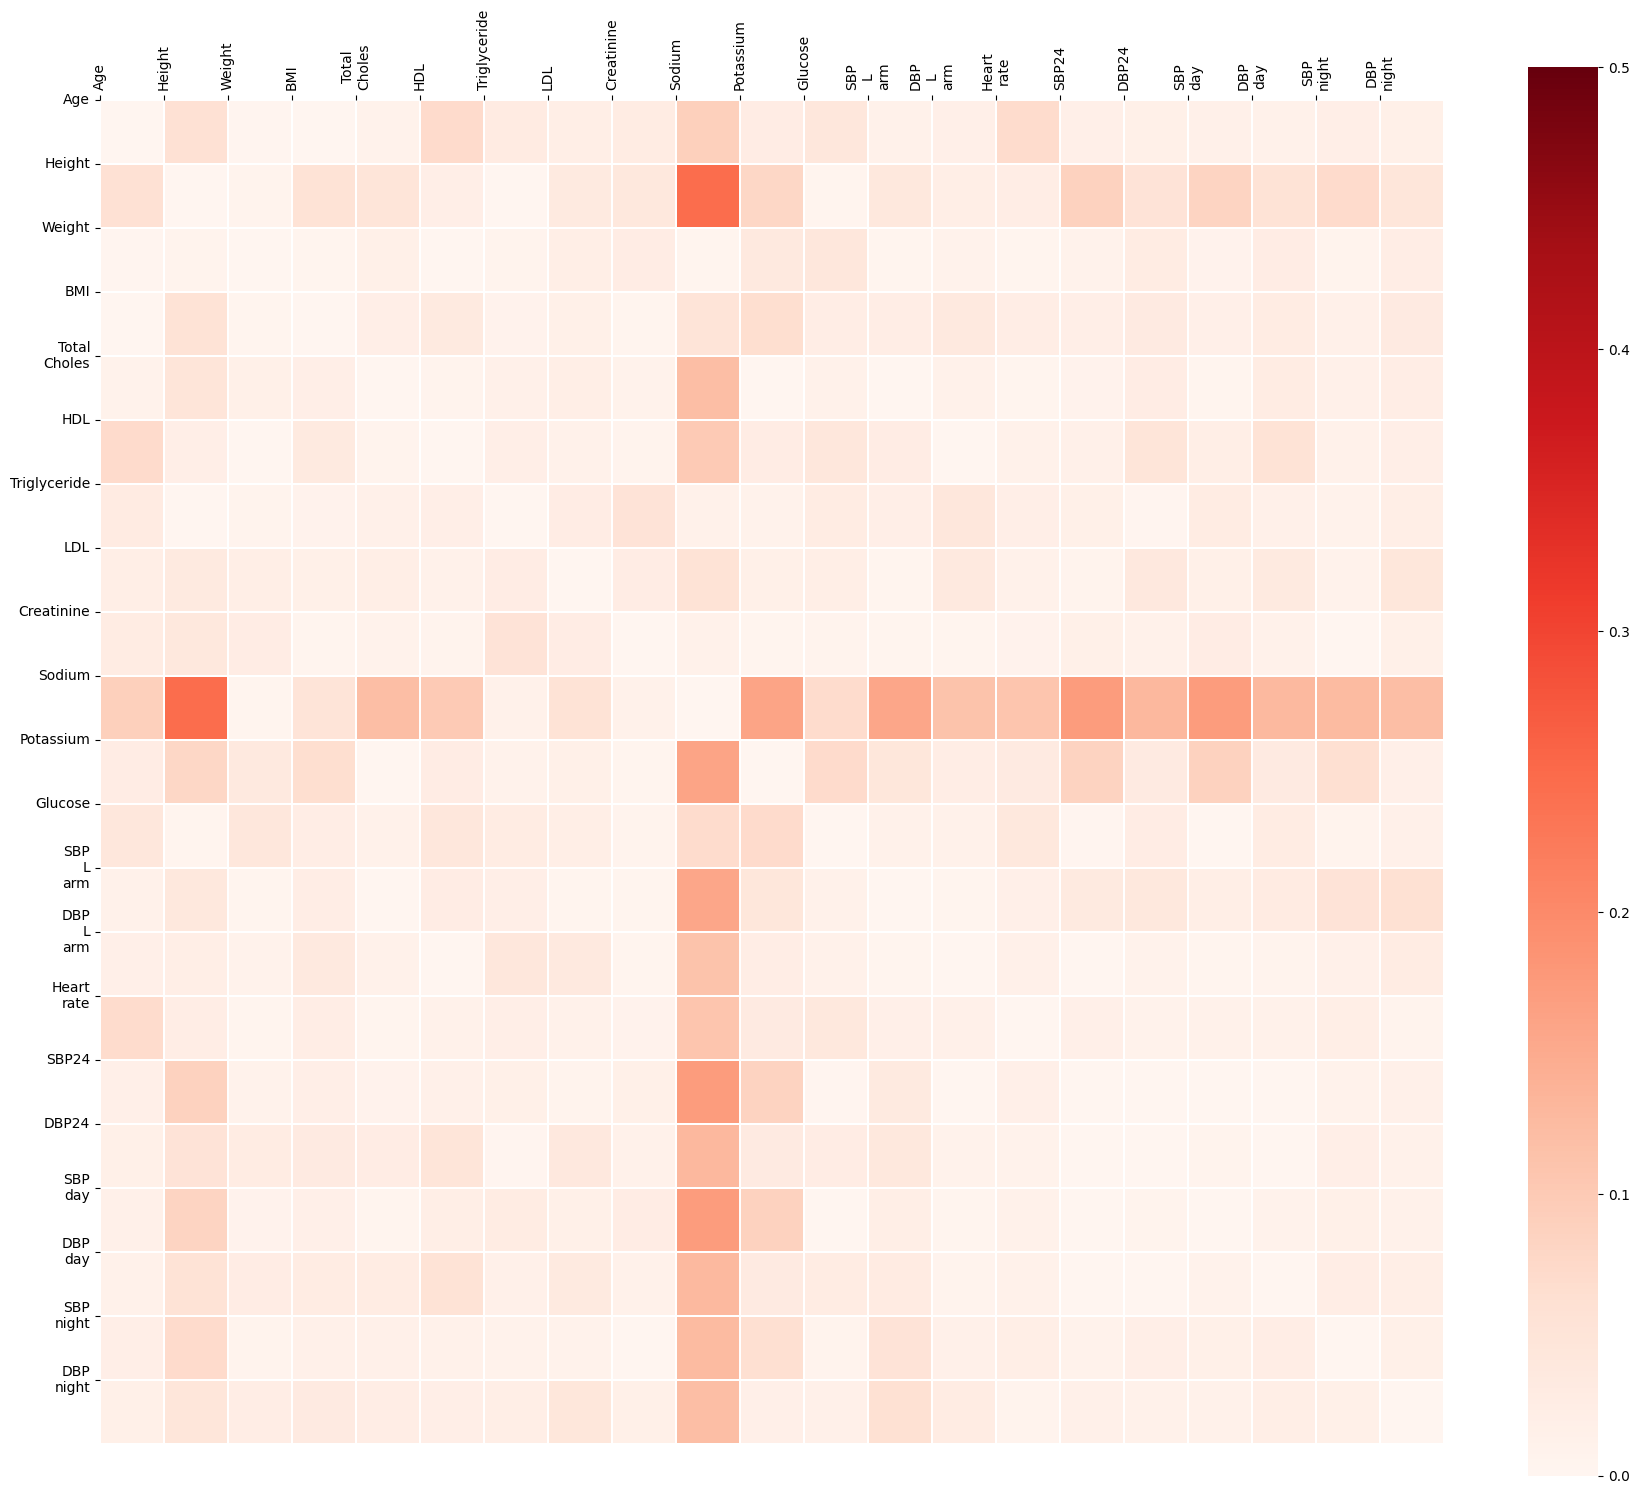

In [24]:
fig3 = plt.figure(figsize=(24, 22))

ax = sns.heatmap(
    corr_diff,
    cmap='Reds',
    vmin=0,
    vmax=0.5,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

short_labels = [c.replace(' ', '\n')[:12] for c in cont_cols]

plt.xticks(range(n), short_labels, rotation=90, fontsize=10)
plt.yticks(range(n), short_labels, fontsize=10)

plt.subplots_adjust(left=0.25, bottom=0.1, right=0.95, top=0.9)

fig3.savefig("Figure2_CombinedCorrelation.png",
             dpi=300,
             bbox_inches='tight')

plt.show()

In [36]:
cont_cols = df_real.select_dtypes(np.number).columns[df_real.nunique() > 5]


In [38]:
df_real = pd.read_excel("DB_orig_totale.xlsx").drop(columns=["ID"], errors="ignore")
df_syn_5x = (
    pd.read_excel("DB_synth_totale.xlsx")
    .drop(columns=["ID"], errors="ignore")
    .iloc[:1460,1:]
    .copy()
)

cont_cols = df_real.select_dtypes(np.number).columns[df_real.nunique() > 5].tolist()

print(f"Real dataset: {df_real.shape}")
print(f"Synthetic dataset: {df_syn_5x.shape}")
print(f"Continuous variables: {len(cont_cols)}")

Real dataset: (292, 41)
Synthetic dataset: (1460, 41)
Continuous variables: 21


In [39]:
cat_cols = df_real.columns.difference(cont_cols)

print(f"Categorical variables ({len(cat_cols)}):")
print(cat_cols.tolist())

Categorical variables (20):
['Alpha-blocker', 'Anti-hypertensive therapy', 'Atorvastatin', 'Atrial Fibrillation', 'Beta-blocker', 'Calcium antagonists', 'Diabetes', 'Dyslipidaemia', 'Ezetimibe', 'HCT/Clortalidone/Indapamide ', 'K-sparing/Antialdosterone', 'Lipid-lowering therapy', 'Other statins', 'RAASi', 'Rosuvastatin', 'Sex', 'Simvastatin', 'Smoking', 'Stroke', 'ischaemic heart disease']


In [40]:
from scipy.stats import chi2_contingency
import itertools

def cramers_v_from_crosstab(contingency):
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        return np.nan

    chi2, p, dof, exp = chi2_contingency(contingency, correction=False)

    n = contingency.to_numpy().sum()
    r, k = contingency.shape

    phi2 = chi2 / n

    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    denom = min(r_corr - 1, k_corr - 1)

    if denom <= 0:
        return np.nan

    return np.sqrt(phi2_corr / denom)


def chi_square_matrix(df, cat_cols):
    results = []

    for var1, var2 in itertools.combinations(cat_cols, 2):
        contingency = pd.crosstab(df[var1], df[var2])

        if contingency.shape[0] > 1 and contingency.shape[1] > 1:
            chi2, p, dof, exp = chi2_contingency(contingency, correction=False)
            cramers_v = cramers_v_from_crosstab(contingency)

            results.append({
                "Var1": var1,
                "Var2": var2,
                "Chi2": chi2,
                "p_value": p,
                "Cramers_V": cramers_v
            })

    return pd.DataFrame(results)

In [41]:
print("\n🔥 Chi-square associations (REAL)...")
chi_real = chi_square_matrix(df_real, cat_cols)

print("🔥 Chi-square associations (SYNTHETIC 5x)...")
chi_syn = chi_square_matrix(df_syn_5x, cat_cols)


🔥 Chi-square associations (REAL)...
🔥 Chi-square associations (SYNTHETIC 5x)...


In [42]:
chi_compare = chi_real.merge(
    chi_syn,
    on=["Var1", "Var2"],
    suffixes=("_Real", "_Syn")
)

chi_compare["Delta_CramersV"] = abs(
    chi_compare["Cramers_V_Real"] - chi_compare["Cramers_V_Syn"]
)

mean_delta = chi_compare["Delta_CramersV"].mean()
max_delta = chi_compare["Delta_CramersV"].max()

print(f"\nMean |Δ Cramér's V|: {mean_delta:.4f}")
print(f"Max  |Δ Cramér's V|: {max_delta:.4f}")


Mean |Δ Cramér's V|: 0.0270
Max  |Δ Cramér's V|: 0.1267



🔥 Combined Cramér's V Matrix (Upper Real | Lower Synthetic)...


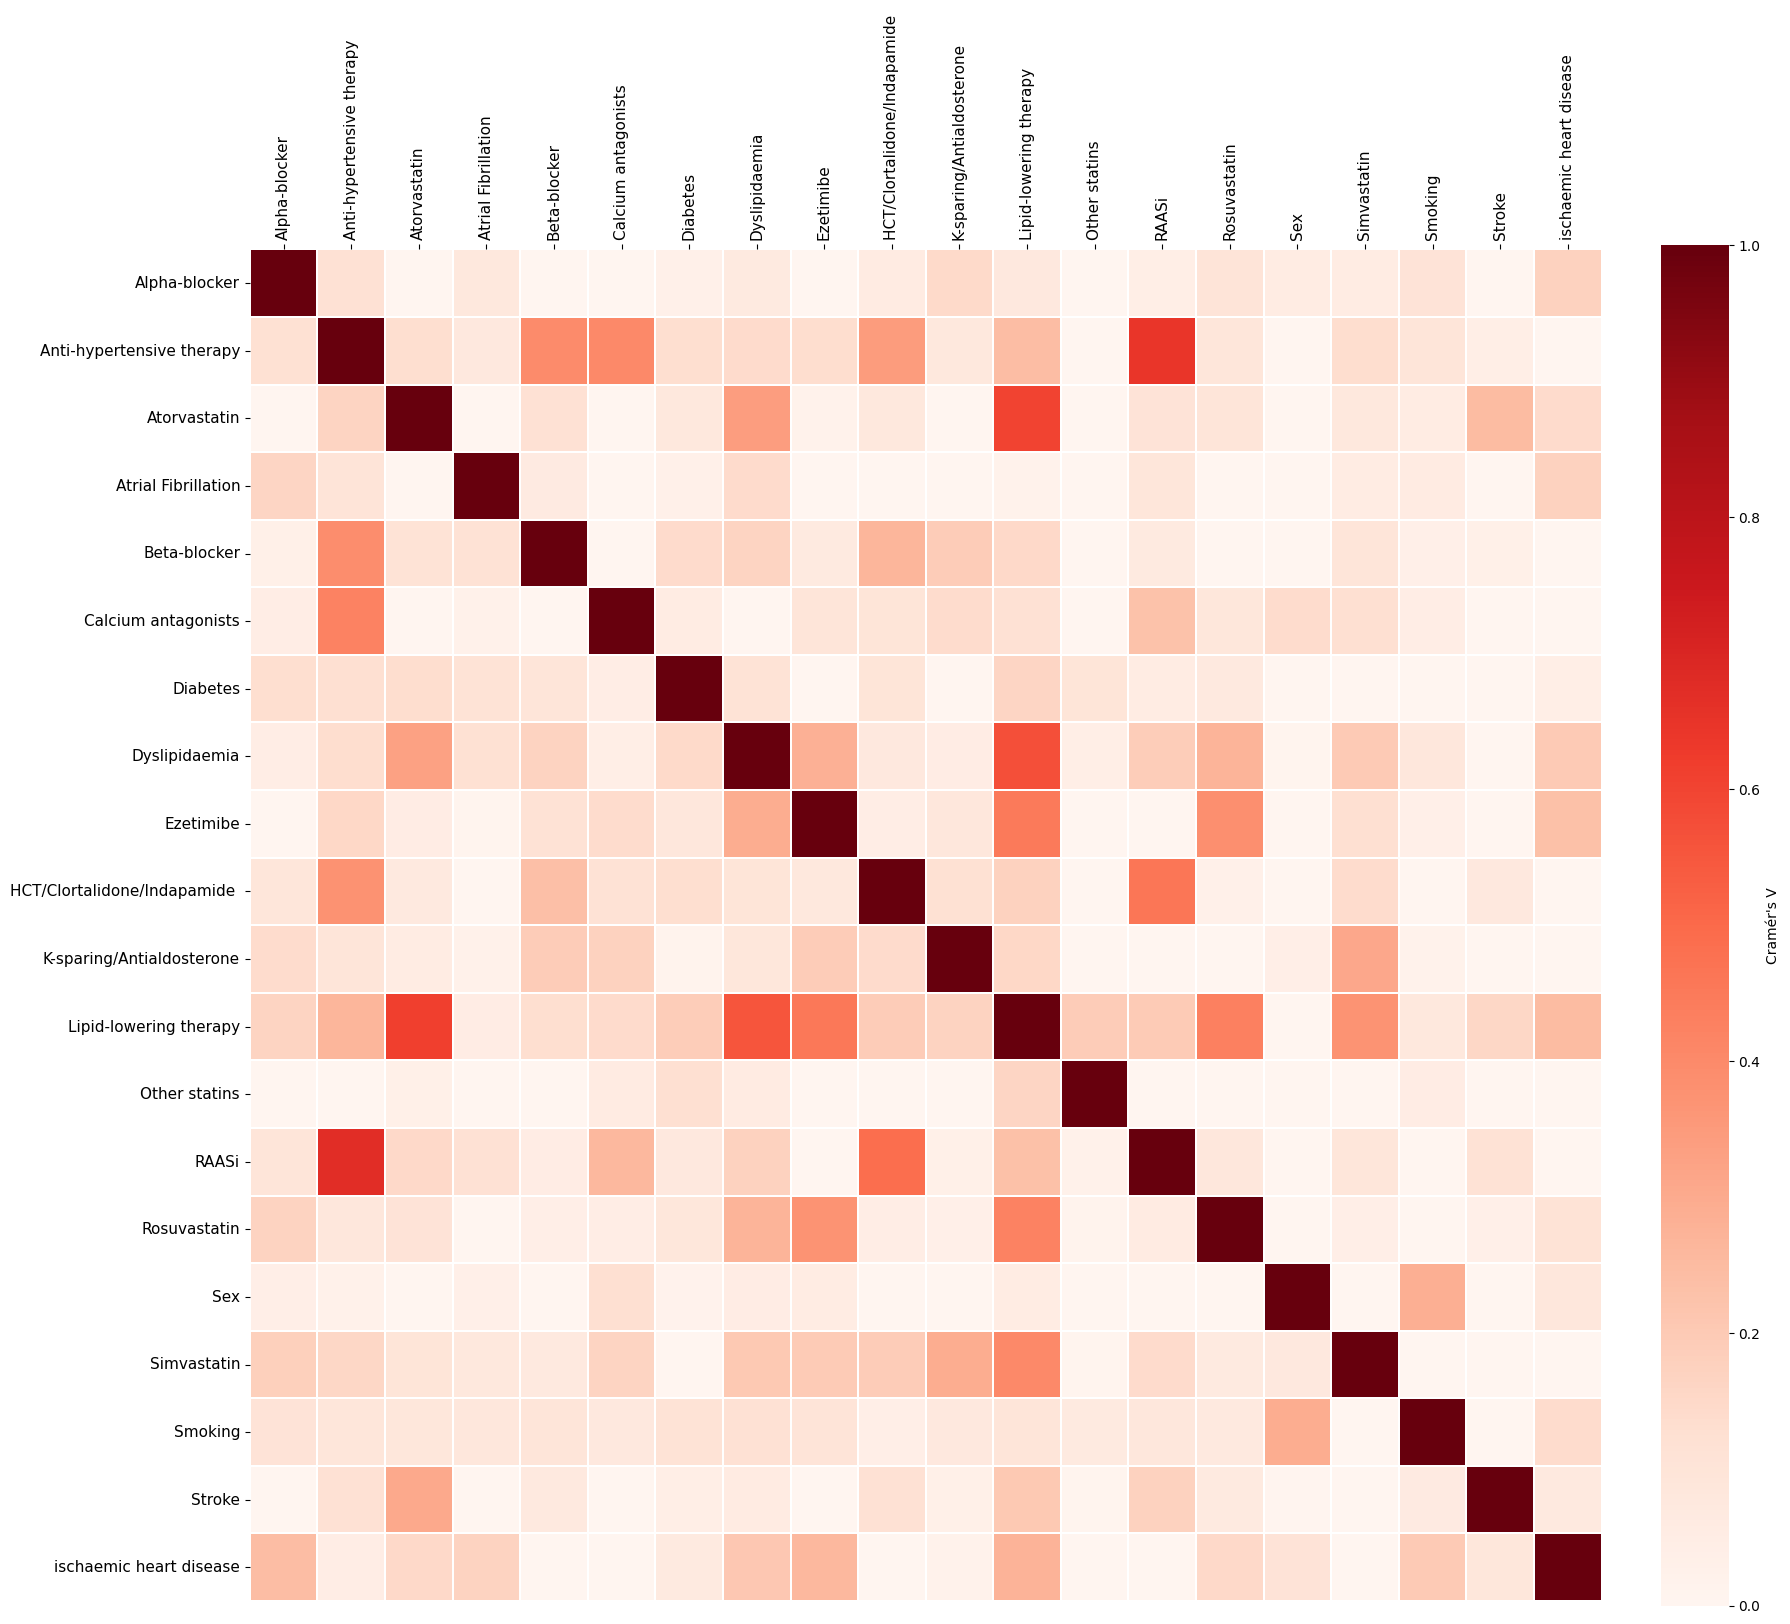

In [44]:
def cramers_v_matrix(df, cat_cols):
    n = len(cat_cols)
    matrix = np.eye(n)

    for i in range(n):
        for j in range(i + 1, n):
            contingency = pd.crosstab(df[cat_cols[i]], df[cat_cols[j]])
            value = cramers_v_from_crosstab(contingency)

            matrix[i, j] = value
            matrix[j, i] = value

    return pd.DataFrame(matrix, index=cat_cols, columns=cat_cols)

print("\nCombined Cramér's V Matrix (Upper Real | Lower Synthetic)...")

cram_real = cramers_v_matrix(df_real, cat_cols)
cram_syn  = cramers_v_matrix(df_syn_5x, cat_cols)

real = cram_real.values
syn  = cram_syn.values
n    = real.shape[0]

upper_mask = np.triu(np.ones((n, n), dtype=bool), k=1)
lower_mask = np.tril(np.ones((n, n), dtype=bool), k=-1)

combined = np.full((n, n), np.nan)

combined[upper_mask] = real[upper_mask]
combined[lower_mask] = syn[lower_mask]

np.fill_diagonal(combined, 1.0)

combined_cram = pd.DataFrame(
    combined,
    index=cat_cols,
    columns=cat_cols
)

fig4, ax = plt.subplots(figsize=(18, 18))

sns.heatmap(
    combined_cram,
    ax=ax,
    cmap="Reds",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={
        "label": "Cramér's V",
        "shrink": 1.0,
        "fraction": 0.046,
        "pad": 0.04
    }
)

ax.set_xticks(np.arange(n) + 0.5)
ax.set_yticks(np.arange(n) + 0.5)

ax.set_xticklabels(
    cat_cols,
    rotation=90,
    ha="center",
    va="bottom",
    fontsize=11
)

ax.set_yticklabels(
    cat_cols,
    rotation=0,
    fontsize=11
)

ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

ax.set_title("")

ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()

fig4.savefig(
    "Figure4_CombinedCramer.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

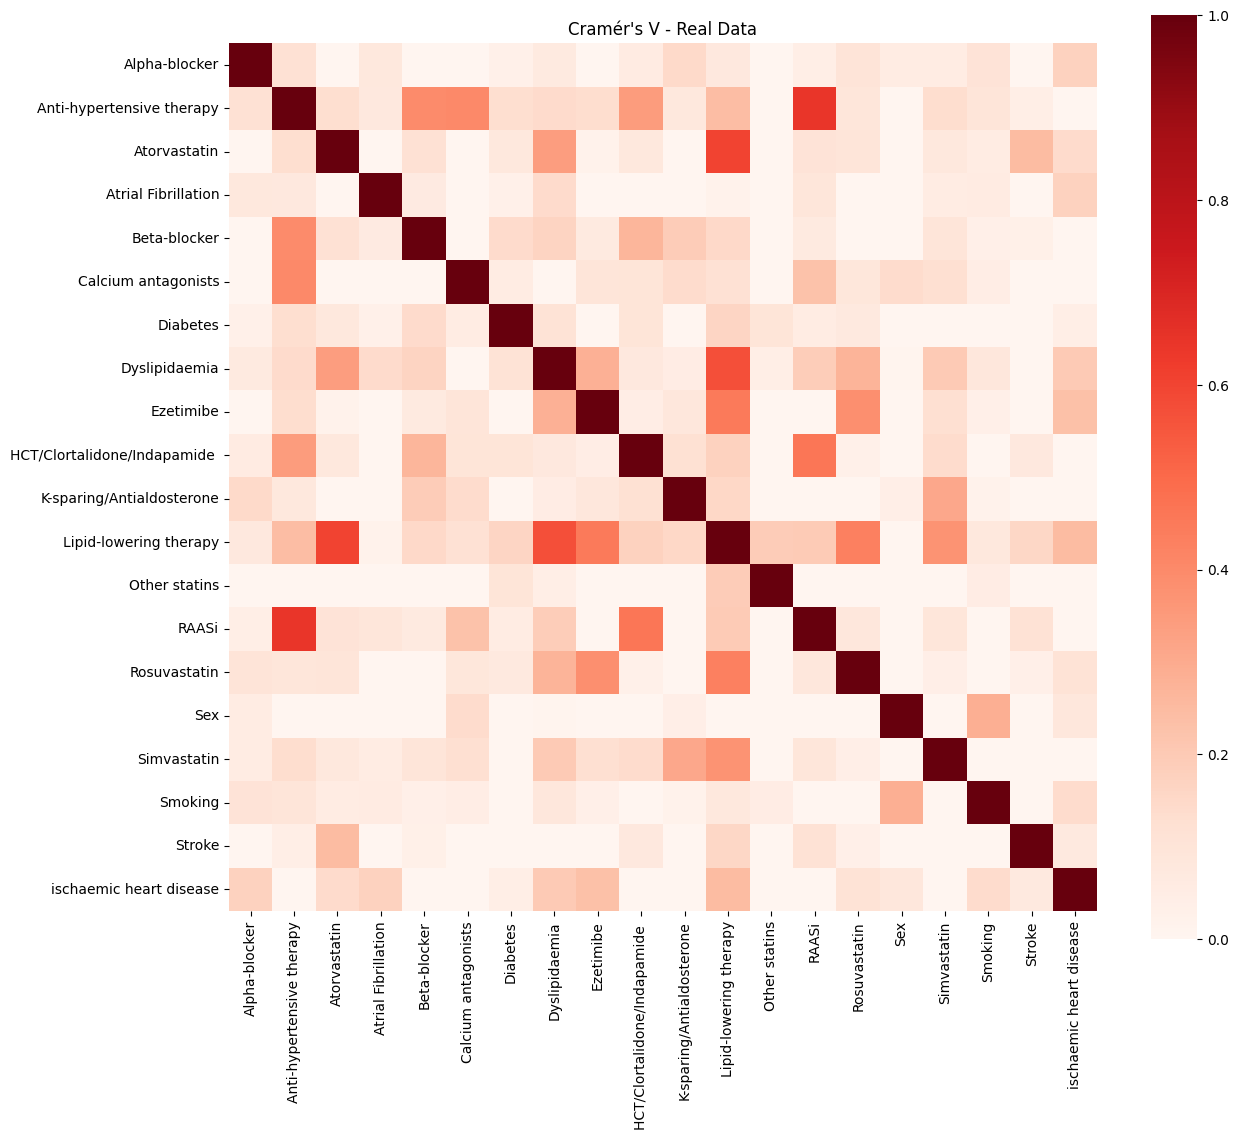

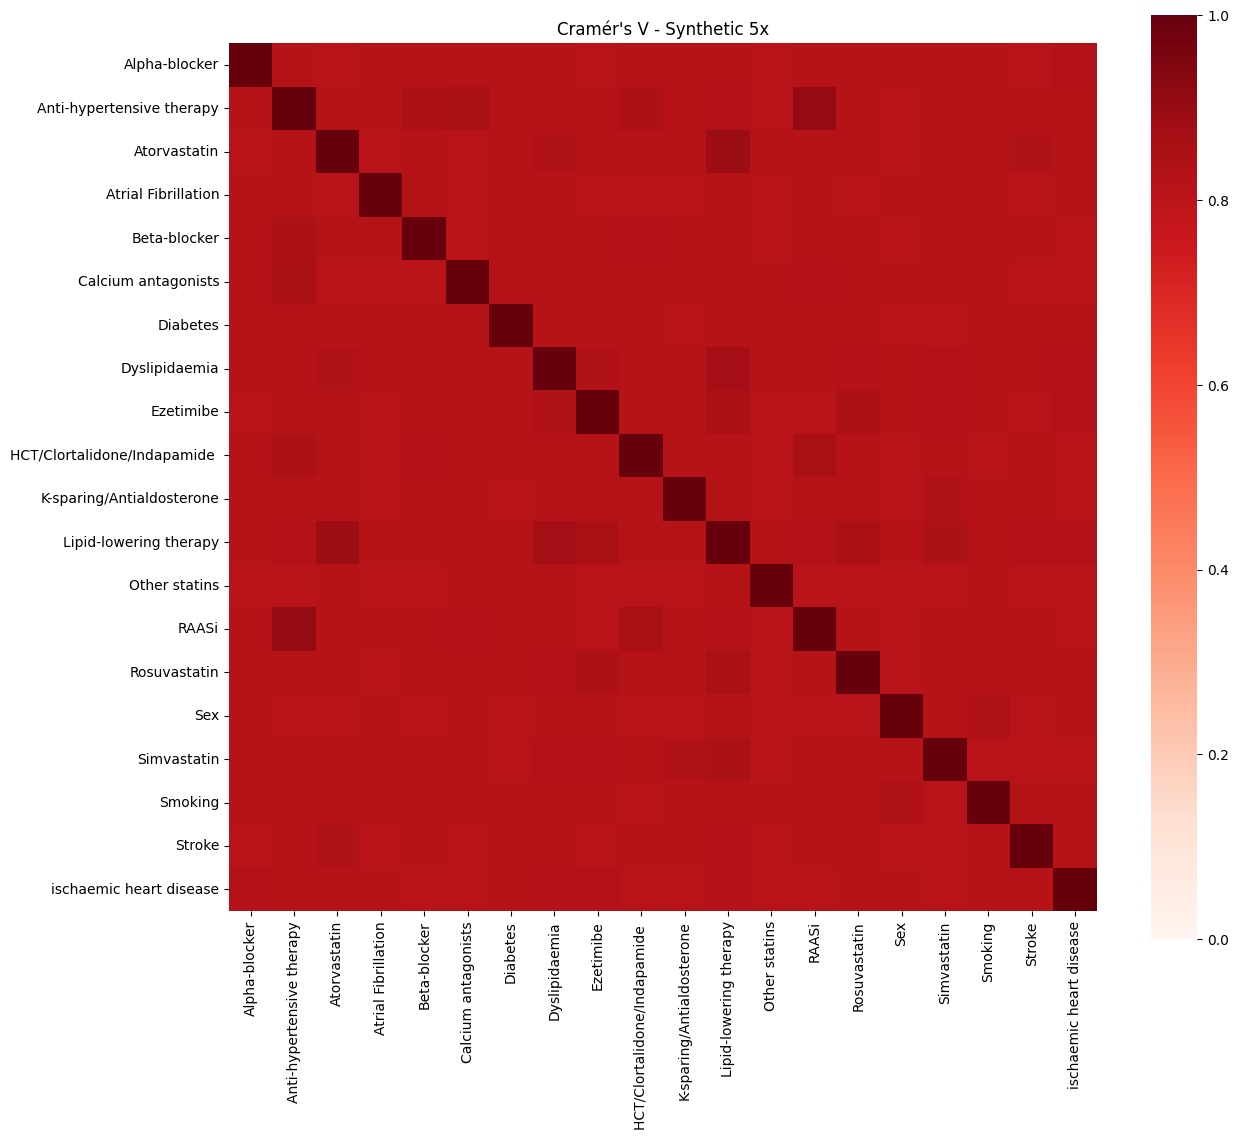

In [32]:
cram_real = cramers_v_matrix(df_real, cat_cols)
cram_syn  = cramers_v_matrix(df_syn_5x, cat_cols)

plt.figure(figsize=(14, 12))
sns.heatmap(cram_real, cmap="Reds", vmin=0, vmax=1, square=True)
plt.title("Cramér's V - Real Data")
plt.show()

plt.figure(figsize=(14, 12))
sns.heatmap(cram_syn, cmap="Reds", vmin=0, vmax=1, square=True)
plt.title("Cramér's V - Synthetic 5x")
plt.show()

In [33]:
delta_cram = abs(cram_real - cram_syn)

upper = np.triu_indices_from(delta_cram, k=1)

median_delta_V = np.nanmedian(delta_cram.values[upper])
mean_delta_V   = np.nanmean(delta_cram.values[upper])
max_delta_V    = np.nanmax(delta_cram.values[upper])

print(f"Median |Δ Cramér's V|: {median_delta_V:.4f}")
print(f"Mean   |Δ Cramér's V|: {mean_delta_V:.4f}")
print(f"Max    |Δ Cramér's V|: {max_delta_V:.4f}")

Median |Δ Cramér's V|: 0.7604
Mean   |Δ Cramér's V|: 0.7294
Max    |Δ Cramér's V|: 0.8185


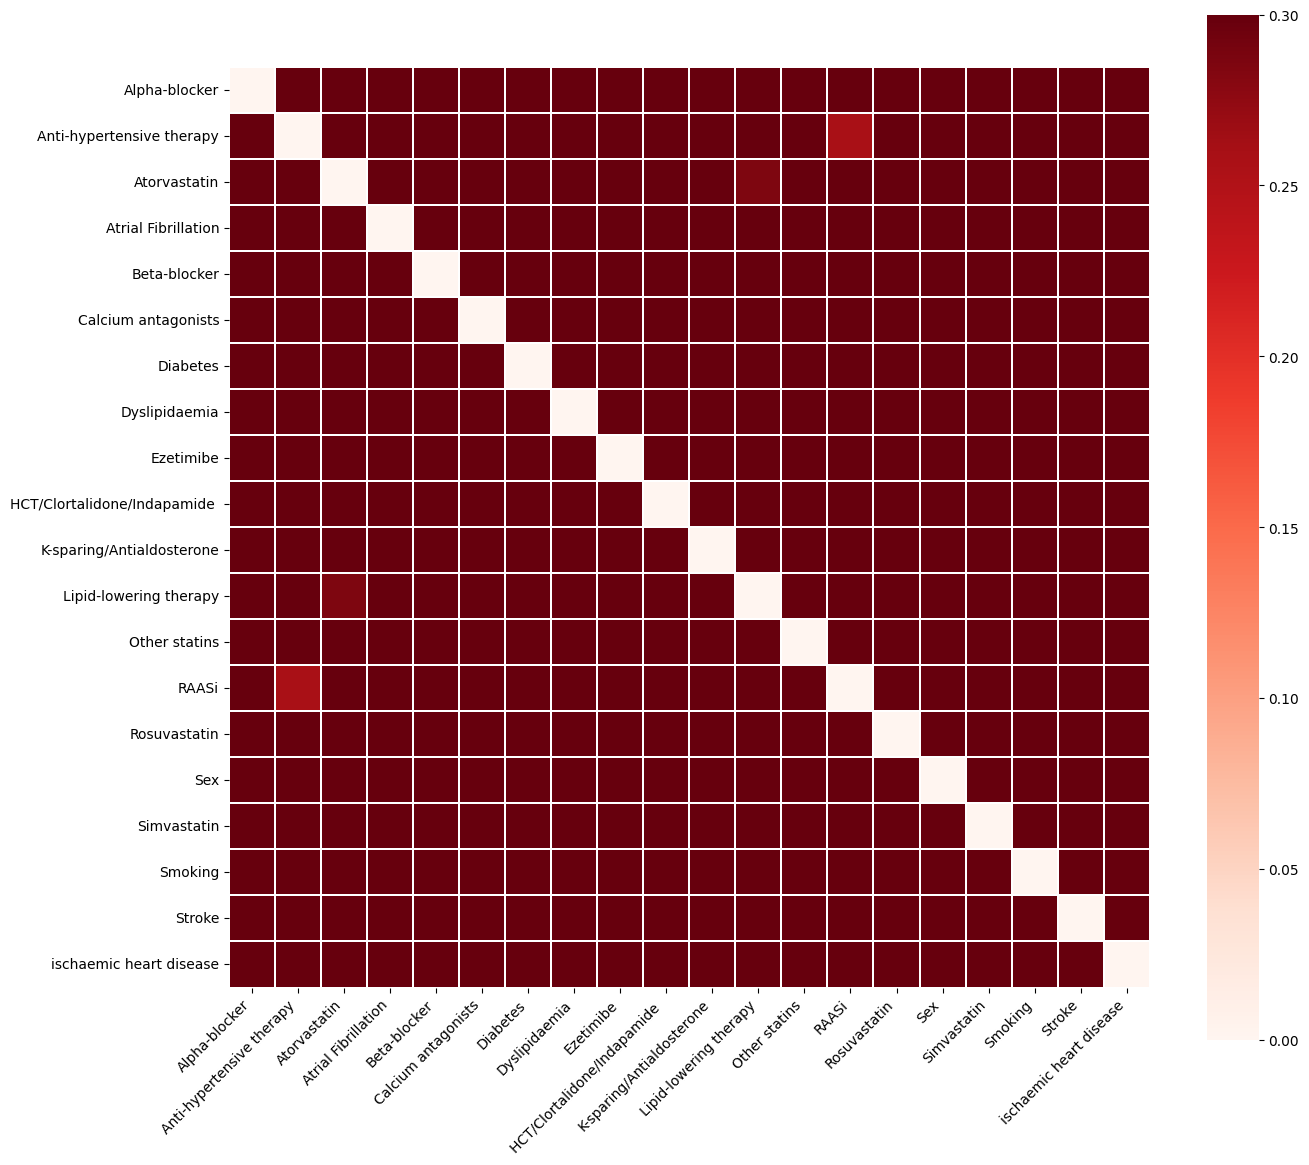

In [34]:
plt.figure(figsize=(14, 12))

sns.heatmap(
    delta_cram,
    cmap="Reds",
    vmin=0,
    vmax=0.3,
    square=True,
    linewidths=0.3
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

fig3.savefig("Figure4_DifferentCramer.png",
             dpi=300,
             bbox_inches='tight')

plt.show()

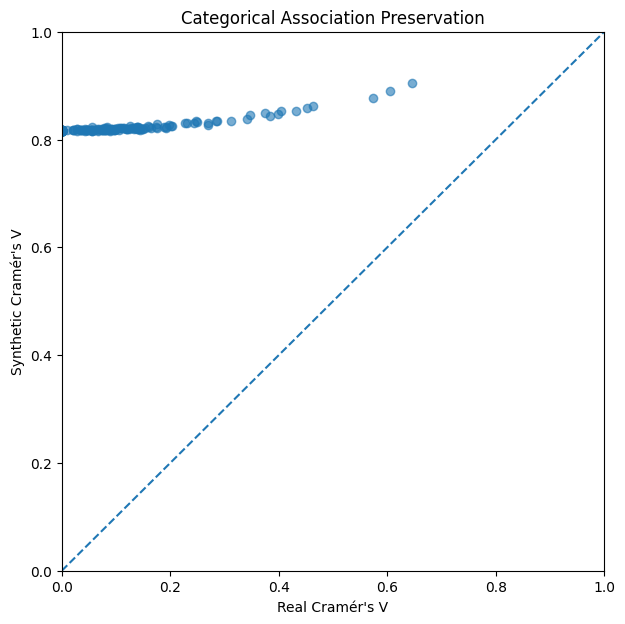

In [35]:
plt.figure(figsize=(7,7))

plt.scatter(
    chi_compare["Cramers_V_Real"],
    chi_compare["Cramers_V_Syn"],
    alpha=0.6
)

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Real Cramér's V")
plt.ylabel("Synthetic Cramér's V")
plt.title("Categorical Association Preservation")
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
import numpy as np
import pandas as pd

analysis_cols = df_real.columns.tolist()

X_real = df_real[analysis_cols].copy()
X_syn = df_syn_5x[analysis_cols].copy()

X_real = X_real.apply(pd.to_numeric, errors="coerce")
X_syn = X_syn.apply(pd.to_numeric, errors="coerce")

X_real = X_real.fillna(X_real.median())
X_syn = X_syn.fillna(X_real.median())

scaler = StandardScaler()
X_real_scaled = scaler.fit_transform(X_real)
X_syn_scaled = scaler.transform(X_syn)

pca = PCA(n_components=3, random_state=42)
real_pca = pca.fit_transform(X_real_scaled)
syn_pca = pca.transform(X_syn_scaled)

explained_var = pca.explained_variance_ratio_

print("PCA explained variance ratio:", explained_var)
print("Total explained variance, first 3 PCs:", explained_var.sum())

PCA explained variance ratio: [0.15764515 0.08577577 0.07465439]
Total explained variance, first 3 PCs: 0.31807530921311244


In [47]:
sed_syn_pairs = pairwise_distances(
    syn_pca,
    syn_pca,
    metric="sqeuclidean"
)

upper = np.triu_indices_from(sed_syn_pairs, k=1)
sed_unique_syn = sed_syn_pairs[upper]

sed_threshold = 0.01
n_close_pairs = np.sum(sed_unique_syn < sed_threshold)
pct_close_pairs = 100 * n_close_pairs / len(sed_unique_syn)

print(f"Synthetic unique pairs: {len(sed_unique_syn):,}")
print(f"Pairs with SED < {sed_threshold}: {n_close_pairs:,}")
print(f"Percentage: {pct_close_pairs:.4f}%")
print(f"Mean SED synthetic pairs: {np.mean(sed_unique_syn):.4f}")
print(f"Median SED synthetic pairs: {np.median(sed_unique_syn):.4f}")

Synthetic unique pairs: 1,065,070
Pairs with SED < 0.01: 3,765
Percentage: 0.3535%
Mean SED synthetic pairs: 26.0098
Median SED synthetic pairs: 20.6815


In [48]:
sed_real_syn = pairwise_distances(
    syn_pca,
    real_pca,
    metric="sqeuclidean"
)

nearest_real_sed = sed_real_syn.min(axis=1)

print(f"Mean nearest real-synthetic SED: {nearest_real_sed.mean():.4f}")
print(f"Median nearest real-synthetic SED: {np.median(nearest_real_sed):.4f}")
print(f"Min nearest real-synthetic SED: {nearest_real_sed.min():.6f}")
print(f"Synthetic records with nearest real SED < {sed_threshold}: {(nearest_real_sed < sed_threshold).sum()}")

Mean nearest real-synthetic SED: 0.0000
Median nearest real-synthetic SED: 0.0000
Min nearest real-synthetic SED: 0.000000
Synthetic records with nearest real SED < 0.01: 1460


In [52]:
from sklearn.metrics import pairwise_distances
import numpy as np

dist_syn = pairwise_distances(
    syn_pca,
    syn_pca,
    metric="euclidean"
)

np.fill_diagonal(dist_syn, np.inf)

min_dist_syn = dist_syn.min(axis=1)

mmd_mean = min_dist_syn.mean()
mmd_sd = min_dist_syn.std()

print(f"Mean Minimum Distance between synthetic records: {mmd_mean:.4f} ± {mmd_sd:.4f}")
print(f"Median Minimum Distance: {np.median(min_dist_syn):.4f}")
print(f"Min Minimum Distance: {min_dist_syn.min():.6f}")
print(f"Max Minimum Distance: {min_dist_syn.max():.4f}")

Mean Minimum Distance between synthetic records: 0.0032 ± 0.0451
Median Minimum Distance: 0.0000
Min Minimum Distance: 0.000000
Max Minimum Distance: 0.9736


In [50]:
n_clusters = 4

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=50)
real_clusters = kmeans.fit_predict(real_pca)
syn_clusters = kmeans.predict(syn_pca)

combined_pca = np.vstack([real_pca, syn_pca])
combined_clusters = np.concatenate([real_clusters, syn_clusters])

csi = silhouette_score(combined_pca, combined_clusters)

print(f"Cluster Separation Index (CSI): {csi:.4f}")

  File "C:\Users\Giulio.amabili\PyCharmMiscProject\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\Giulio.amabili\PyCharmMiscProject\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Giulio.amabili\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Giulio.amabili\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
      

Cluster Separation Index (CSI): 0.2945


In [54]:
from sklearn.metrics import pairwise_distances

sed_threshold = 0.01

sed_syn = pairwise_distances(
    syn_pca,
    syn_pca,
    metric="sqeuclidean"
)

np.fill_diagonal(sed_syn, np.inf)

min_sed_syn = sed_syn.min(axis=1)

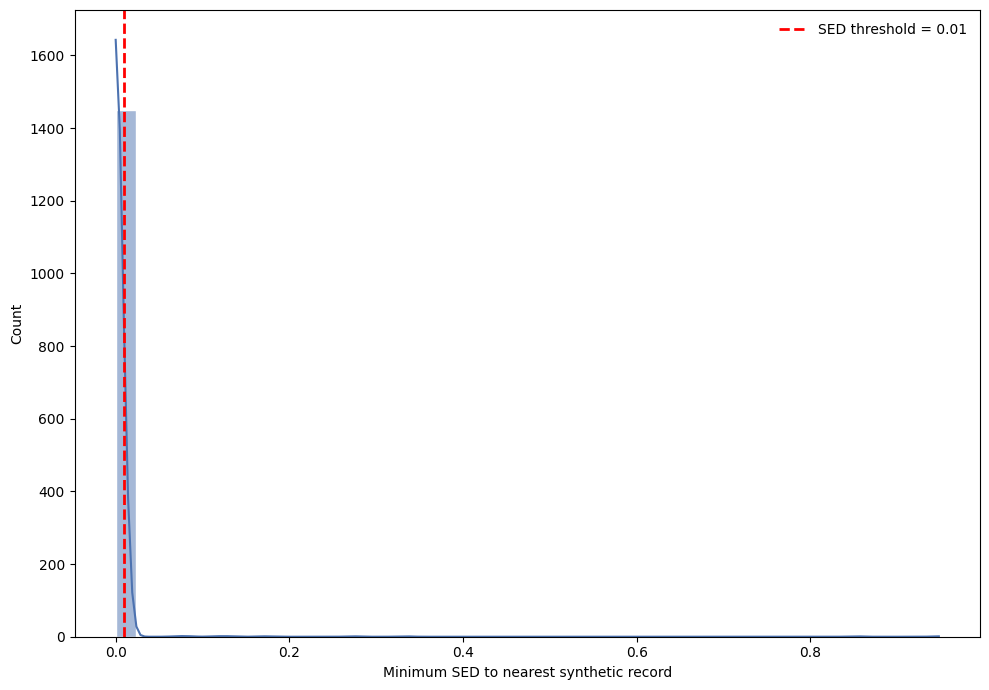

In [55]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.histplot(
    min_sed_syn,
    bins=40,
    kde=True,
    color="#4C72B0",
    edgecolor="white",
    ax=ax
)

ax.axvline(
    sed_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"SED threshold = {sed_threshold}"
)

ax.set_xlabel("Minimum SED to nearest synthetic record")
ax.set_ylabel("Count")
ax.set_title("")
ax.legend(frameon=False)

plt.tight_layout()

fig.savefig(
    "Figure_Minimum_SED_Histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

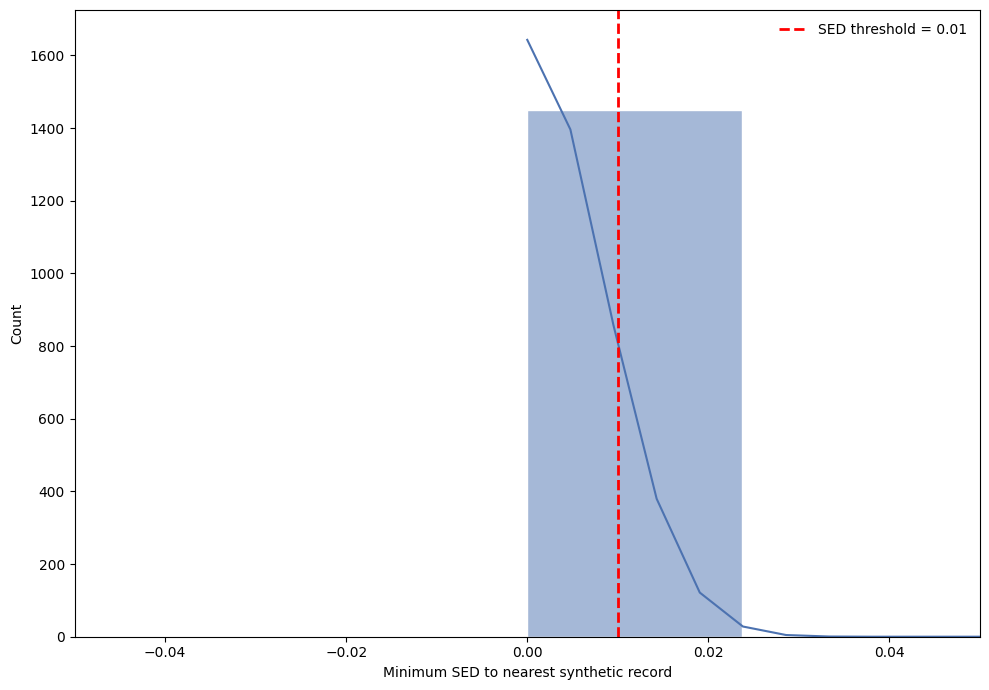

In [56]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.histplot(
    min_sed_syn,
    bins=40,
    kde=True,
    color="#4C72B0",
    edgecolor="white",
    ax=ax
)

ax.axvline(
    sed_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"SED threshold = {sed_threshold}"
)

ax.set_xlim(0, np.percentile(min_sed_syn, 99))
ax.set_xlabel("Minimum SED to nearest synthetic record")
ax.set_ylabel("Count")
ax.set_title("")
ax.legend(frameon=False)

plt.tight_layout()

fig.savefig(
    "Figure_Minimum_SED_Histogram_Zoomed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

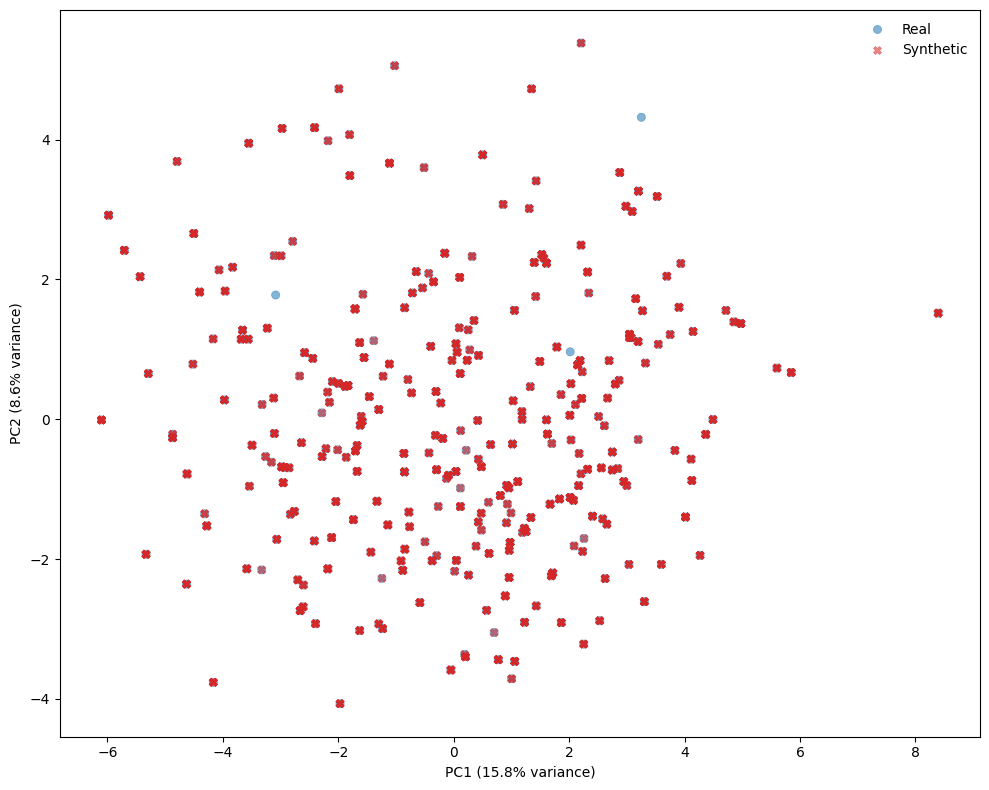

In [57]:
pca_plot_df = pd.DataFrame({
    "PC1": np.concatenate([real_pca[:, 0], syn_pca[:, 0]]),
    "PC2": np.concatenate([real_pca[:, 1], syn_pca[:, 1]]),
    "Dataset": ["Real"] * real_pca.shape[0] + ["Synthetic"] * syn_pca.shape[0]
})

fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="Dataset",
    style="Dataset",
    palette={
        "Real": "#1F77B4",
        "Synthetic": "#D62728"
    },
    alpha=0.55,
    s=35,
    edgecolor=None,
    ax=ax
)

ax.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_var[1]*100:.1f}% variance)")
ax.set_title("")
ax.legend(frameon=False)

plt.tight_layout()

fig.savefig(
    "Figure_PCA_Real_vs_Synthetic_PC1_PC2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
records_below_threshold = np.sum(min_sed_syn < sed_threshold)
pct_records_below_threshold = 100 * records_below_threshold / len(min_sed_syn)

print(f"Records with minimum SED < {sed_threshold}: {records_below_threshold}")
print(f"Percentage of synthetic records: {pct_records_below_threshold:.4f}%")

Records with minimum SED < 0.01: 1451
Percentage of synthetic records: 99.3836%


In [58]:
sed_syn_pairs = pairwise_distances(
    syn_pca,
    syn_pca,
    metric="sqeuclidean"
)

upper = np.triu_indices_from(sed_syn_pairs, k=1)
sed_unique_syn = sed_syn_pairs[upper]

n_close_pairs = np.sum(sed_unique_syn < sed_threshold)
pct_close_pairs = 100 * n_close_pairs / len(sed_unique_syn)

print(f"Pairs with SED < {sed_threshold}: {n_close_pairs}")
print(f"Percentage of unique synthetic pairs: {pct_close_pairs:.4f}%")

Pairs with SED < 0.01: 3765
Percentage of unique synthetic pairs: 0.3535%


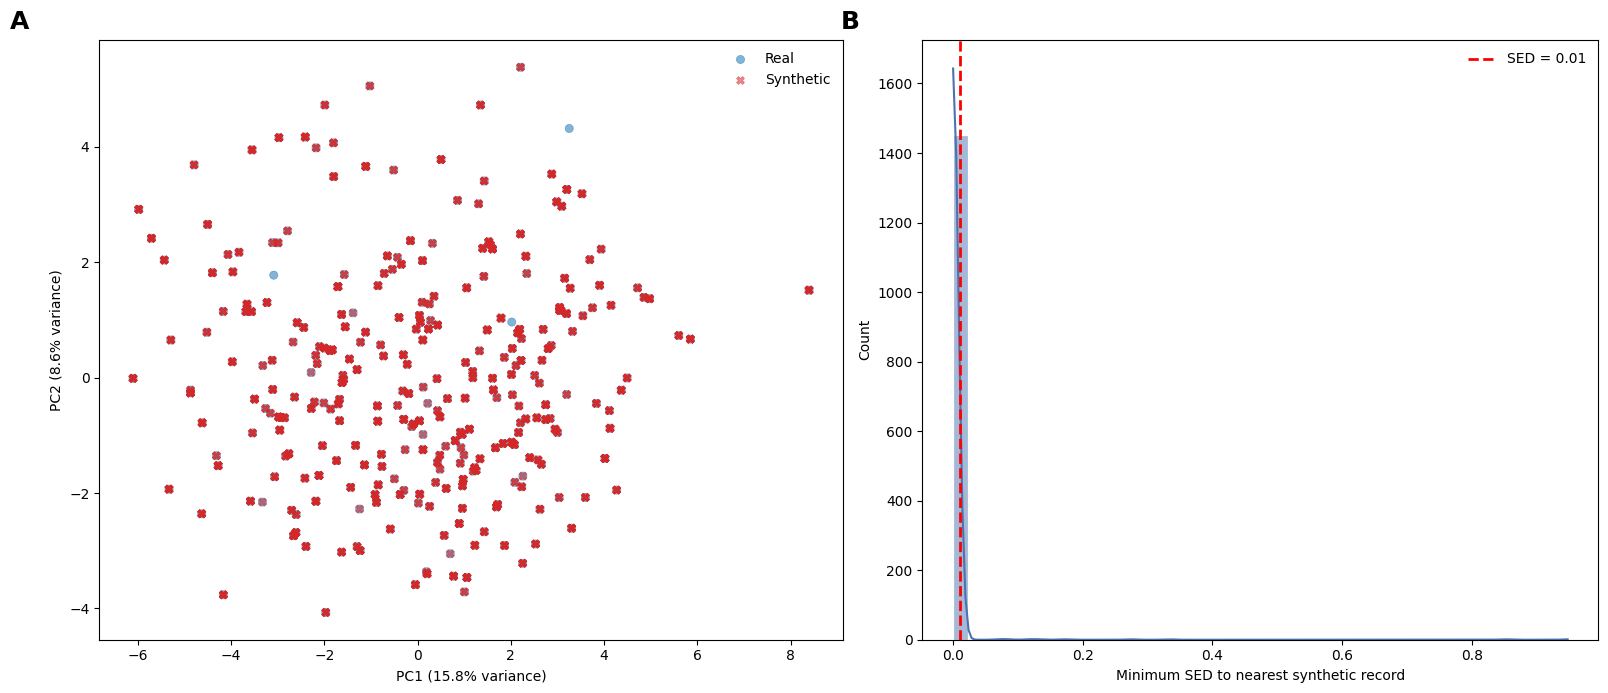

In [60]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 7),
    gridspec_kw={"width_ratios": [1.1, 1]}
)

pca_plot_df = pd.DataFrame({
    "PC1": np.concatenate([real_pca[:, 0], syn_pca[:, 0]]),
    "PC2": np.concatenate([real_pca[:, 1], syn_pca[:, 1]]),
    "Dataset": ["Real"] * real_pca.shape[0] + ["Synthetic"] * syn_pca.shape[0]
})

sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="Dataset",
    style="Dataset",
    palette={
        "Real": "#1F77B4",
        "Synthetic": "#D62728"
    },
    alpha=0.55,
    s=35,
    edgecolor=None,
    ax=axes[0]
)

axes[0].set_xlabel(f"PC1 ({explained_var[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({explained_var[1]*100:.1f}% variance)")
axes[0].set_title("")
axes[0].legend(frameon=False, loc="best")

sns.histplot(
    min_sed_syn,
    bins=40,
    kde=True,
    color="#4C72B0",
    edgecolor="white",
    ax=axes[1]
)

axes[1].axvline(
    sed_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"SED = {sed_threshold}"
)

axes[1].set_xlabel("Minimum SED to nearest synthetic record")
axes[1].set_ylabel("Count")
axes[1].set_title("")
axes[1].legend(frameon=False, loc="best")

axes[0].text(
    -0.12, 1.05, "A",
    transform=axes[0].transAxes,
    fontsize=18,
    fontweight="bold",
    va="top"
)

axes[1].text(
    -0.12, 1.05, "B",
    transform=axes[1].transAxes,
    fontsize=18,
    fontweight="bold",
    va="top"
)

plt.tight_layout()

fig.savefig(
    "Figure_Privacy_Diversity_Assessment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()